# 金融对话数值推理模型：SFT → 轻量 DPO / GRPO → benchmark 评估

目标：训练一个面向 **金融对话数值推理** 的 reasoning model。

整体闭环：
- **SFT-1（FinQA）**：先学习表文混合数值推理与程序监督
- **SFT-2（ConvFinQA）**：再学习多轮对话中的 follow-up 数值推理
- **DPO（可选）**：小规模优化表达质量、结构和少废话
- **GRPO（推荐）**：基于可验证 reward 优化答案正确性、程序一致性与结构约束
- **benchmark 评估**：`FinQA / ConvFinQA + CFLUE + FinanceBench + AdaptLLM/finance-tasks`

本 Notebook 复用 MedicalGPT 的训练框架：
- 数据格式遵循 `docs/datasets.md`
- pipeline 参考 `run_training_dpo_pipeline.ipynb`


## 环境准备

如果你在全新环境运行，请先安装依赖；已按项目 README 配好可跳过。


In [ ]:
import torch

# 查看 PyTorch 版本
print("PyTorch 版本:", torch.__version__)

# 查看 CUDA 版本（当前PyTorch使用的CUDA）
print("CUDA 版本:", torch.version.cuda)

# 查看是否启用GPU
print("CUDA 是否可用:", torch.cuda.is_available())

In [ ]:
%pip install -r requirements.txt --upgrade

In [ ]:
%pip install modelscope


In [1]:
# HF Mirror（可选）
import os
HF_ENDPOINT = "https://hf-mirror.com"
os.environ["HF_ENDPOINT"] = HF_ENDPOINT
print("HF_ENDPOINT:", os.getenv("HF_ENDPOINT"))


HF_ENDPOINT: https://hf-mirror.com


## 任务配置

这里把配置拆成五部分：
1. 阶段一数据 `SFT-1 (FinQA)`
2. 阶段二数据 `SFT-2 (ConvFinQA)`
3. 原始数据下载缓存目录
4. 转换 / 清洗 / 混合目录
5. 训练与评估输出目录


In [2]:
from pathlib import Path
import json
import random
from itertools import islice

BASE_MODEL = "/root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct"

TEMPLATE_NAME = "qwen"
RANDOM_SEED = 42
FORCE_REDOWNLOAD_RAW = False

# ==== 数据处理主链配置 ====
SFT_VARIANT = "benchmark_sft"  # benchmark_sft: Answer 使用 answer_norm；assistant_sft: Answer 使用 answer_display
STRICT_TIERS = "A"             # 默认只训练 A 档；B 档需要修复/抽检后再显式设为 A,B
SFT2_REQUIRES_HISTORY_RATIO = 0.70
SFT2_OTHER_CONVFINQA_RATIO = 0.20
SFT2_FINQA_REPLAY_RATIO = 0.10

# ==== 根路径统一配置（数据盘） ====
DISK_ROOT = Path("/root/autodl-tmp")
DATA_DIR = DISK_ROOT / "data" / "financial_reasoning_v2"
OUTPUT_ROOT = DISK_ROOT / "outputs" / "financial_reasoning_v2"

RAW_CACHE_DIR = DISK_ROOT / "data" / "financial_reasoning" / "raw"
SFT1_SFT_DIR = DATA_DIR / "sft1_sharegpt"
SFT2_SFT_DIR = DATA_DIR / "sft2_sharegpt"
DPO_DIR = DATA_DIR / "dpo_pairs"
NORMALIZED_DIR = DATA_DIR / "normalized"
ROUTER_AUDIT_DIR = DATA_DIR / "audit"
MIXED_DIR = DATA_DIR / "mixed"
CLEAN_DIR = DATA_DIR / "clean"
REPORT_DIR = DATA_DIR / "reports"

SFT1_MIXED_FILE = MIXED_DIR / "train_sft1_mixed.jsonl"
SFT2_MIXED_FILE = MIXED_DIR / "train_sft2_mixed.jsonl"
DPO_MIXED_FILE = DPO_DIR / "train_reasoning_dpo.jsonl"
SFT1_CLEAN_FILE = CLEAN_DIR / "train_sft1_clean.jsonl"
SFT2_CLEAN_FILE = CLEAN_DIR / "train_sft2_clean.jsonl"
SFT1_NORMALIZED_DIR = NORMALIZED_DIR / "sft1"
SFT2_NORMALIZED_DIR = NORMALIZED_DIR / "sft2"
SFT1_ROUTER_AUDIT_DIR = ROUTER_AUDIT_DIR / "sft1"
SFT2_ROUTER_AUDIT_DIR = ROUTER_AUDIT_DIR / "sft2"

SFT1_DIR = CLEAN_DIR / "sft1_dir_strict"
SFT2_DIR = CLEAN_DIR / "sft2_dir_strict"
DPO_TRAIN_DIR = DPO_DIR / "train_dir"

SFT1_AUDIT_DIR = CLEAN_DIR / "audit_sft1"
SFT2_AUDIT_DIR = CLEAN_DIR / "audit_sft2"
SFT1_STRICT_FILE = CLEAN_DIR / "train_sft1_clean_strict.jsonl"
SFT2_STRICT_FILE = CLEAN_DIR / "train_sft2_clean_strict.jsonl"
SFT2_CONVFINQA_ONLY_FILE = CLEAN_DIR / "train_sft2_convfinqa_only_strict.jsonl"
SFT2_FINQA_REPLAY_FILE = CLEAN_DIR / "train_sft2_finqa_replay.jsonl"

# 训练/日志输出改到数据盘
SFT1_OUT = OUTPUT_ROOT / "sft1"
SFT1_MERGED_OUT = OUTPUT_ROOT / "sft1_merged"
SFT2_OUT = OUTPUT_ROOT / "sft2"
SFT2_MERGED_OUT = OUTPUT_ROOT / "sft2_merged"
DPO_OUT = OUTPUT_ROOT / "dpo"
DPO_MERGED_OUT = OUTPUT_ROOT / "dpo_merged"
TB_LOG_DIR = OUTPUT_ROOT / "tensorboard"

for d in [
    RAW_CACHE_DIR, SFT1_SFT_DIR, SFT2_SFT_DIR, DPO_DIR, NORMALIZED_DIR, ROUTER_AUDIT_DIR,
    SFT1_NORMALIZED_DIR, SFT2_NORMALIZED_DIR, SFT1_ROUTER_AUDIT_DIR, SFT2_ROUTER_AUDIT_DIR,
    MIXED_DIR, CLEAN_DIR, REPORT_DIR,
    SFT1_DIR, SFT2_DIR, DPO_TRAIN_DIR, SFT1_AUDIT_DIR, SFT2_AUDIT_DIR, OUTPUT_ROOT, TB_LOG_DIR,
    SFT1_OUT, SFT1_MERGED_OUT, SFT2_OUT, SFT2_MERGED_OUT, DPO_OUT, DPO_MERGED_OUT,
]:
    d.mkdir(parents=True, exist_ok=True)

SFT1_DATA_SPECS = [
    {
        "name": "finqa_train",
        "family": "finqa",
        "source_type": "local",
        "local_path": RAW_CACHE_DIR / "finqa" / "train.json",
        "split": "train",
        "weight": 1.0,
        "max_rows": None,
        "sft_variant": SFT_VARIANT,
        "strict_tiers": STRICT_TIERS,
        "description": "阶段一：表格 + 文本 + 程序推理（FinQA strict-A）",
    },
]

SFT2_DATA_SPECS = [
    {
        "name": "fingpt_convfinqa_train",
        "family": "convfinqa_turn",
        "source_type": "local",
        "local_path": RAW_CACHE_DIR / "convfinqa_turn" / "train_turn.json",
        "split": "train",
        "weight": 1.0,
        "max_rows": None,
        "sft_variant": SFT_VARIANT,
        "strict_tiers": STRICT_TIERS,
        "description": "阶段二：ConvFinQA turn-level multiturn + history QA（strict-A）",
    },
]

BENCHMARK_SPECS = [
    {"name": "ConvFinQA_dev", "role": "核心多轮数值推理"},
    {"name": "FinQA_dev", "role": "核心表文混合推理"},
]


def allocate_target_rows(specs, total_budget: int, default_cap: int | None = None):
    if not specs:
        return []
    total_weight = sum(max(float(spec.get("weight", 0.0)), 0.0) for spec in specs)
    if total_weight <= 0:
        raise ValueError("All dataset weights are zero; cannot allocate target_rows.")

    allocated = []
    for spec in specs:
        raw_target = int(round(total_budget * float(spec.get("weight", 0.0)) / total_weight))
        cap = spec.get("max_rows", default_cap)
        if cap is not None:
            raw_target = min(raw_target, int(cap))
        spec = dict(spec)
        spec["target_rows"] = max(raw_target, 0)
        allocated.append(spec)
    return allocated

print("DISK_ROOT:", DISK_ROOT)
print("DATA_DIR:", DATA_DIR)
print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("BASE_MODEL:", BASE_MODEL)
print("SFT_VARIANT:", SFT_VARIANT, "STRICT_TIERS:", STRICT_TIERS)
print("SFT2 mixture:", {
    "requires_history": SFT2_REQUIRES_HISTORY_RATIO,
    "convfinqa_other": SFT2_OTHER_CONVFINQA_RATIO,
    "finqa_replay": SFT2_FINQA_REPLAY_RATIO,
})
print("SFT1_DATA_SPECS:", json.dumps([{**spec, "local_path": str(spec.get("local_path", ""))} for spec in SFT1_DATA_SPECS], ensure_ascii=False, indent=2))
print("SFT2_DATA_SPECS:", json.dumps([{**spec, "local_path": str(spec.get("local_path", ""))} for spec in SFT2_DATA_SPECS], ensure_ascii=False, indent=2))
print("BENCHMARK_SPECS:", json.dumps(BENCHMARK_SPECS, ensure_ascii=False, indent=2))


DISK_ROOT: /root/autodl-tmp
DATA_DIR: /root/autodl-tmp/data/financial_reasoning_v2
OUTPUT_ROOT: /root/autodl-tmp/outputs/financial_reasoning_v2
BASE_MODEL: /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct
SFT_VARIANT: benchmark_sft STRICT_TIERS: A
SFT2 mixture: {'requires_history': 0.7, 'convfinqa_other': 0.2, 'finqa_replay': 0.1}
SFT1_DATA_SPECS: [
  {
    "name": "finqa_train",
    "family": "finqa",
    "source_type": "local",
    "local_path": "/root/autodl-tmp/data/financial_reasoning/raw/finqa/train.json",
    "split": "train",
    "weight": 1.0,
    "max_rows": null,
    "sft_variant": "benchmark_sft",
    "strict_tiers": "A",
    "description": "阶段一：表格 + 文本 + 程序推理（FinQA strict-A）"
  }
]
SFT2_DATA_SPECS: [
  {
    "name": "fingpt_convfinqa_train",
    "family": "convfinqa_turn",
    "source_type": "local",
    "local_path": "/root/autodl-tmp/data/financial_reasoning/raw/convfinqa_turn/train_turn.json",
    "split": "train",
    "weight": 1.0,
    "max_rows": null,
    "sft_var

### 统一任务格式

本次两阶段 SFT 的主训练模板：
- **FinQA**：文本 + 表格 + 问题 -> 当前样本的 `Evidence / Program / Answer`
- **ConvFinQA**：历史状态 + 当前 turn 问题 + 表格/文本上下文 -> 当前 turn 的 `Evidence / Program / Answer`

ConvFinQA 的字段口径必须区分 current turn 与 final QA：
- 当前 turn question：优先 `annotation.cur_dial[-1]`，缺失时 fallback 到 `annotation.dialogue_break[turn_ind]`
- 当前 turn program：优先 `annotation.cur_program`
- 当前 turn answer：优先 `annotation.exe_ans`
- `qa.question / qa.program_re / qa.exe_ans` 是整题最终问题和最终 program，只能进入 raw metadata 或作为缺失字段 fallback，不能作为 turn-level 主监督

MedicalGPT 对数据格式的要求：
- **SFT**：`conversations`
- **DPO**：`question + response_chosen + response_rejected`

> 注：路由器仍支持 `fineval/fiqa_qa` family，但当前 notebook 的 SFT 两阶段不使用它们。


## 数据集处理流程



### 下载原始数据到本地缓存

这一阶段只负责下载 raw 数据，避免每次重跑 notebook 都重复下载。
- `url_json`：直接下载官方 JSON 文件
- `hf`：通过 `datasets.load_dataset` 落地到本地 jsonl
- 若缓存已存在且 `FORCE_REDOWNLOAD_RAW=False`，则直接跳过


In [3]:
import json
from datasets import load_dataset

ALL_DATA_SPECS = SFT1_DATA_SPECS + SFT2_DATA_SPECS


def raw_cache_file(spec: dict) -> Path:
    if spec["source_type"] == "local":
        return Path(spec["local_path"])
    return RAW_CACHE_DIR / spec["family"] / f"{spec['name']}.jsonl"

raw_files = {}
for spec in ALL_DATA_SPECS:
    cache_file = raw_cache_file(spec)
    raw_files[spec["name"]] = cache_file
    cache_file.parent.mkdir(parents=True, exist_ok=True)

    if spec["source_type"] == "local":
        if not cache_file.exists():
            raise FileNotFoundError(f"Missing local raw file: {cache_file}")
        print(f"[use local] {spec['name']} -> {cache_file}")
        continue

    if cache_file.exists() and not FORCE_REDOWNLOAD_RAW:
        print(f"[skip] use cached raw file: {cache_file}")
        continue

    print(f"[download] {spec['name']} -> {cache_file}")
    if spec["source_type"] == "hf":
        ds = load_dataset(spec["dataset_name"], split=spec["split"])
        with cache_file.open('w', encoding='utf-8') as f:
            for row in ds:
                f.write(json.dumps(dict(row), ensure_ascii=False) + "\n")
    else:
        raise ValueError(f"Unsupported source_type: {spec['source_type']}")
    print(f"[saved] {cache_file}")


[use local] finqa_train -> /root/autodl-tmp/data/financial_reasoning/raw/finqa/train.json
[use local] fingpt_convfinqa_train -> /root/autodl-tmp/data/financial_reasoning/raw/convfinqa_turn/train_turn.json


### 格式匹配

这一阶段只读取本地 raw 文件，并通过包入口执行当前数据处理主链：
- `python -m financial_data_processors --task sft`：生成 strict SFT，同时可选导出 `normalized / audit`
- `python -m financial_data_processors --task dpo`：基于 strict target 生成轻量 DPO pair

当前 SFT target 固定为英文三段式：`Evidence / Program / Answer`。

In [4]:

import json
import subprocess
import pandas as pd

sft_reports = []
dpo_reports = []

for spec in ALL_DATA_SPECS:
    raw_file = raw_files[spec['name']]
    is_sft1 = spec in SFT1_DATA_SPECS
    out_dir = SFT1_SFT_DIR if is_sft1 else SFT2_SFT_DIR
    norm_dir = SFT1_NORMALIZED_DIR if is_sft1 else SFT2_NORMALIZED_DIR
    audit_dir = SFT1_ROUTER_AUDIT_DIR if is_sft1 else SFT2_ROUTER_AUDIT_DIR

    sft_file = out_dir / f"{spec['name']}_sharegpt.jsonl"
    normalized_file = norm_dir / f"{spec['name']}_normalized.jsonl"
    audit_file = audit_dir / f"{spec['name']}_audit.jsonl"
    dpo_file = DPO_DIR / f"{spec['name']}_dpo.jsonl"

    common_router_args = [
        '--source_file', str(raw_file),
        '--dataset_family', spec['family'],
        '--sft_variant', spec.get('sft_variant', SFT_VARIANT),
        '--strict_tiers', spec.get('strict_tiers', STRICT_TIERS),
    ]
    sharegpt_cmd = [
        'python', '-m', 'financial_data_processors',
        '--task', 'sft',
        '--output_file', str(sft_file),
        '--normalized_output_file', str(normalized_file),
        '--audit_output_file', str(audit_file),
        *common_router_args,
    ]
    dpo_cmd = [
        'python', '-m', 'financial_data_processors',
        '--task', 'dpo',
        '--output_file', str(dpo_file),
        '--seed', str(RANDOM_SEED),
        *common_router_args,
    ]

    print(' '.join(sharegpt_cmd))
    sharegpt_result = subprocess.run(sharegpt_cmd, check=True, capture_output=True, text=True)
    print(sharegpt_result.stdout)
    sft_reports.append(json.loads(sharegpt_result.stdout))

    print(' '.join(dpo_cmd))
    dpo_result = subprocess.run(dpo_cmd, check=True, capture_output=True, text=True)
    print(dpo_result.stdout)
    dpo_reports.append(json.loads(dpo_result.stdout))

print('[SFT conversion reports]')
print(json.dumps(sft_reports, ensure_ascii=False, indent=2))
print('[DPO conversion reports]')
print(json.dumps(dpo_reports, ensure_ascii=False, indent=2))

sft_summary_rows = []
for r in sft_reports:
    for fam, stats in r.get('per_family', {}).items():
        sft_summary_rows.append({
            'dataset_family': r.get('dataset_family', ''),
            'family': fam,
            'sft_variant': r.get('sft_variant'),
            'strict_tiers': r.get('strict_tiers'),
            'input_rows': stats.get('input_rows', 0),
            'strict_saved_rows': stats.get('saved_rows', 0),
            'normalized_rows': stats.get('normalized_rows', 0),
            'audit_rows': stats.get('audit_rows', 0),
            'tier_A_rows': stats.get('tier_A_rows', 0),
            'tier_B_rows': stats.get('tier_B_rows', 0),
            'tier_C_rows': stats.get('tier_C_rows', 0),
            'requires_history_rows': stats.get('requires_history_rows', 0),
            'multiturn_history_rows': stats.get('multiturn_history_rows', 0),
            'history_answer_missing_rows': stats.get('history_answer_missing_rows', 0),
            'history_full_reasoning_rows': stats.get('history_full_reasoning_rows', 0),
            'history_question_only_rows': stats.get('history_question_only_rows', 0),
            'history_full_reasoning_turns': stats.get('history_full_reasoning_turns', 0),
            'history_question_only_turns': stats.get('history_question_only_turns', 0),
            'rendered_history_full_reasoning_turns': stats.get('rendered_history_full_reasoning_turns', 0),
            'rendered_history_question_only_turns': stats.get('rendered_history_question_only_turns', 0),
            'duplicate_current_question_in_history_source_rows': stats.get('duplicate_current_question_in_history_source_rows', 0),
            'current_answer_leaked_in_history_source_rows': stats.get('current_answer_leaked_in_history_source_rows', 0),
            'question_semantic_risk_rows': stats.get('question_semantic_risk_rows', 0),
            'question_text_suspicious_rows': stats.get('question_text_suspicious_rows', 0),
            'weak_table_evidence_rendering_rows': stats.get('weak_table_evidence_rendering_rows', 0),
            'evidence_not_in_rendered_prompt_rows': stats.get('evidence_not_in_rendered_prompt_rows', 0),
            'evidence_visible_in_prompt_rows': stats.get('evidence_visible_in_prompt_rows', 0),
            'duplicate_current_question_in_history_rows': stats.get('duplicate_current_question_in_history_rows', 0),
            'current_answer_leaked_in_history_rows': stats.get('current_answer_leaked_in_history_rows', 0),
            'table_evidence_column_pruned_rows': stats.get('table_evidence_column_pruned_rows', 0),
            'exact_evidence_alignment_rows': stats.get('exact_evidence_alignment_rows', 0),
            'program_answer_match_rows': stats.get('program_answer_match_rows', 0),
            'raw_program_unchanged_rows': stats.get('raw_program_unchanged_rows', 0),
            'json_like_evidence_rows': stats.get('json_like_evidence_rows', 0),
        })

sft_summary_df = pd.DataFrame(sft_summary_rows)
print()
print('[SFT strict/normalized/audit summary table]')
display(sft_summary_df)

dpo_summary_rows = []
for r in dpo_reports:
    pf = r.get('dpo_post_filter', {})
    dpo_summary_rows.append({
        'dataset_family': r.get('dataset_family', ''),
        'input_rows': r.get('input_rows', 0),
        'saved_rows': r.get('saved_rows', 0),
        'skipped_rows': r.get('skipped_rows', 0),
        'post_filter_input_rows': pf.get('post_filter_input_rows', 0),
        'post_filter_saved_rows': pf.get('post_filter_saved_rows', 0),
        'post_filter_skipped_rows': pf.get('post_filter_skipped_rows', 0),
        'post_filter_duplicate_pair_rows': pf.get('post_filter_duplicate_pair_rows', 0),
        'post_filter_not_comparable_rows': pf.get('post_filter_not_comparable_rows', 0),
        'post_filter_rejected_too_short_rows': pf.get('post_filter_rejected_too_short_rows', 0),
    })

dpo_summary_df = pd.DataFrame(dpo_summary_rows)
print()
print('[DPO post-filter summary table]')
display(dpo_summary_df)


python -m financial_data_processors --task sft --output_file /root/autodl-tmp/data/financial_reasoning_v2/sft1_sharegpt/finqa_train_sharegpt.jsonl --normalized_output_file /root/autodl-tmp/data/financial_reasoning_v2/normalized/sft1/finqa_train_normalized.jsonl --audit_output_file /root/autodl-tmp/data/financial_reasoning_v2/audit/sft1/finqa_train_audit.jsonl --source_file /root/autodl-tmp/data/financial_reasoning/raw/finqa/train.json --dataset_family finqa --sft_variant benchmark_sft --strict_tiers A
{
  "task": "sft",
  "output_file": "/root/autodl-tmp/data/financial_reasoning_v2/sft1_sharegpt/finqa_train_sharegpt.jsonl",
  "normalized_output_file": "/root/autodl-tmp/data/financial_reasoning_v2/normalized/sft1/finqa_train_normalized.jsonl",
  "audit_output_file": "/root/autodl-tmp/data/financial_reasoning_v2/audit/sft1/finqa_train_audit.jsonl",
  "dataset_family": "finqa",
  "sft_variant": "benchmark_sft",
  "strict_tiers": "A",
  "input_rows": 6251,
  "saved_rows": 3701,
  "skipped_

,dataset_family,family,sft_variant,strict_tiers,input_rows,strict_saved_rows,normalized_rows,audit_rows,tier_A_rows,tier_B_rows,...,weak_table_evidence_rendering_rows,evidence_not_in_rendered_prompt_rows,evidence_visible_in_prompt_rows,duplicate_current_question_in_history_rows,current_answer_leaked_in_history_rows,table_evidence_column_pruned_rows,exact_evidence_alignment_rows,program_answer_match_rows,raw_program_unchanged_rows,json_like_evidence_rows
0,finqa,finqa,benchmark_sft,A,6251,3701,6251,2550,3701,751,...,0,1382,4869,0,0,1773,6251,5703,6251,0
1,convfinqa_turn,convfinqa_turn,benchmark_sft,A,11104,6147,11104,4957,6147,2118,...,0,2432,8672,16,0,2393,11104,10825,11104,0



[DPO post-filter summary table]


,dataset_family,input_rows,saved_rows,skipped_rows,post_filter_input_rows,post_filter_saved_rows,post_filter_skipped_rows,post_filter_duplicate_pair_rows,post_filter_not_comparable_rows,post_filter_rejected_too_short_rows
0,finqa,6251,3674,2577,3701,3674,27,27,0,0
1,convfinqa_turn,11104,6133,4971,6147,6133,14,14,0,0


展示转换后的 `ConvFinQA / FinQA` SFT 样例，确认模板、表格上下文、历史对话和推理程序是否正常。

关键检查：

1. `FinQA` 是单轮表文推理：prompt 中使用 `Question:`，target 固定为 `Evidence / Program / Answer`。
2. `ConvFinQA` 是 turn-level multiturn：prompt 中使用 `Current question:`，该问题必须来自当前 turn，而不是 `qa.question` 的整题最终问题。
3. ConvFinQA history 优先渲染前序完整推理块：`Q + Evidence + Program + Answer`。拿不到可靠前序监督时才使用 question-only fallback。

ConvFinQA 正确样例形态：

```text
Conversation history:
Q: what is the net cash from operating activities in 2009?
Evidence:
- year ended june 30 , cash provided by operations increased $ 25587 to $ 206588 ...

Program: 206588
Answer: 206588

Current question: what about in 2008?

Respond exactly in this format:
Evidence:
- ...

Program: ...
Answer: ...
```

对应 target 应该是当前 turn，而不是最终 percentage change：

```text
Evidence:
- year ended june 30 , cash provided by operations increased $ 25587 to $ 206588 ...

Program: 181001
Answer: 181001
```

metadata 中应同时可见：
- `raw_metadata.current_question / current_program / current_exe_ans`
- `raw_metadata.final_question / final_program_re / final_exe_ans`

如果 `Current question` 等于 `final_question`，而当前 turn 不是最后一轮，说明数据处理又退化成 final-QA 监督，需要停止训练并修复。


### Strict 数据混合

`financial_data_processors` 已在转换阶段完成：
- `program_re` 执行校验
- evidence exact 对齐
- `answer_norm` 选择
- strict / normalized / audit 分流

因此这里不再执行旧的 `clean -> audit_sharegpt -> filter_sharegpt_by_audit` 主过滤流程，而是直接对 router 产出的 strict SFT 文件做抽样与合并，生成训练目录需要的 jsonl。

In [5]:
def sample_jsonl_records(path: Path, target_rows: int | None = None, seed: int = 42):
    with path.open('r', encoding='utf-8') as f:
        records = [line for line in f if line.strip()]
    if target_rows is None or target_rows <= 0 or len(records) <= target_rows:
        return records
    rng = random.Random(seed)
    idxs = list(range(len(records)))
    rng.shuffle(idxs)
    idxs = sorted(idxs[:target_rows])
    return [records[i] for i in idxs]


def sample_records(records, target_rows: int | None = None, seed: int = 42):
    records = list(records)
    if target_rows is None or target_rows <= 0 or len(records) <= target_rows:
        return records
    rng = random.Random(seed)
    idxs = list(range(len(records)))
    rng.shuffle(idxs)
    idxs = sorted(idxs[:target_rows])
    return [records[i] for i in idxs]


def read_jsonl_objects(path: Path):
    raw = path.read_text(encoding='utf-8')
    decoder = json.JSONDecoder()
    rows = []
    pos = 0
    bad_chunks = []
    literal_separator_count = 0

    while pos < len(raw):
        while pos < len(raw) and raw[pos].isspace():
            pos += 1
        while raw.startswith('\\n', pos):
            literal_separator_count += 1
            pos += 2
            while pos < len(raw) and raw[pos].isspace():
                pos += 1
        if pos >= len(raw):
            break
        try:
            obj, next_pos = decoder.raw_decode(raw, pos)
        except json.JSONDecodeError as e:
            bad_chunks.append({
                'char_pos': pos,
                'message': str(e),
                'snippet': raw[pos:pos + 160],
            })
            break
        rows.append(obj)
        pos = next_pos

    report = {
        'path': str(path),
        'rows': len(rows),
        'bad_chunks': len(bad_chunks),
        'literal_separator_count': literal_separator_count,
    }
    return rows, report, bad_chunks


def write_jsonl_objects(path: Path, rows):
    with path.open('w', encoding='utf-8') as wf:
        for row in rows:
            wf.write(json.dumps(row, ensure_ascii=False) + '\n')

In [6]:
# 1) SFT1 (FinQA) strict 抽样 + 混合
with SFT1_STRICT_FILE.open("w", encoding="utf-8") as wf:
    for spec in SFT1_DATA_SPECS:
        path = SFT1_SFT_DIR / f"{spec['name']}_sharegpt.jsonl"
        sampled = sample_jsonl_records(path, spec.get("target_rows"), seed=RANDOM_SEED)
        for line in sampled:
            wf.write(line if line.endswith("\n") else line + "\n")

SFT1_MIXED_FILE.write_text(SFT1_STRICT_FILE.read_text(encoding="utf-8"), encoding="utf-8")
SFT1_CLEAN_FILE.write_text(SFT1_STRICT_FILE.read_text(encoding="utf-8"), encoding="utf-8")

# 2) SFT2: ConvFinQA turn-level multiturn + FinQA replay
convfinqa_rows = []
for spec in SFT2_DATA_SPECS:
    path = SFT2_SFT_DIR / f"{spec['name']}_sharegpt.jsonl"
    rows, _, bad = read_jsonl_objects(path)
    if bad:
        raise ValueError(f"Invalid SFT2 source JSONL: {path} -> {bad[0]}")
    convfinqa_rows.extend(rows)

requires_history_rows = [r for r in convfinqa_rows if (r.get("metadata") or {}).get("requires_history")]
other_convfinqa_rows = [r for r in convfinqa_rows if not (r.get("metadata") or {}).get("requires_history")]

sft2_target_rows = sum((spec.get("target_rows") or 0) for spec in SFT2_DATA_SPECS) or None
if sft2_target_rows:
    history_target = int(round(sft2_target_rows * SFT2_REQUIRES_HISTORY_RATIO))
    other_target = int(round(sft2_target_rows * SFT2_OTHER_CONVFINQA_RATIO))
    replay_target = max(0, sft2_target_rows - history_target - other_target)
else:
    history_target = len(requires_history_rows)
    other_target = len(other_convfinqa_rows)
    conv_selected_estimate = history_target + other_target
    replay_target = int(round(conv_selected_estimate * SFT2_FINQA_REPLAY_RATIO / max(SFT2_REQUIRES_HISTORY_RATIO + SFT2_OTHER_CONVFINQA_RATIO, 1e-9)))

selected_history = sample_records(requires_history_rows, history_target, seed=RANDOM_SEED)
selected_other = sample_records(other_convfinqa_rows, other_target, seed=RANDOM_SEED + 1)
finqa_replay_rows, _, bad = read_jsonl_objects(SFT1_STRICT_FILE)
if bad:
    raise ValueError(f"Invalid FinQA replay JSONL: {SFT1_STRICT_FILE} -> {bad[0]}")
selected_replay = sample_records(finqa_replay_rows, replay_target, seed=RANDOM_SEED + 2)

sft2_rows = selected_history + selected_other + selected_replay
random.Random(RANDOM_SEED).shuffle(sft2_rows)

write_jsonl_objects(SFT2_CONVFINQA_ONLY_FILE, selected_history + selected_other)
write_jsonl_objects(SFT2_FINQA_REPLAY_FILE, selected_replay)
write_jsonl_objects(SFT2_STRICT_FILE, sft2_rows)

SFT2_MIXED_FILE.write_text(SFT2_STRICT_FILE.read_text(encoding="utf-8"), encoding="utf-8")
SFT2_CLEAN_FILE.write_text(SFT2_STRICT_FILE.read_text(encoding="utf-8"), encoding="utf-8")

# Make train_file_dir-style folders (最终训练集使用 strict 版本)
(SFT1_DIR / "train_sft1_clean_strict.jsonl").write_text(SFT1_STRICT_FILE.read_text(encoding="utf-8"), encoding="utf-8")
(SFT2_DIR / "train_sft2_clean_strict.jsonl").write_text(SFT2_STRICT_FILE.read_text(encoding="utf-8"), encoding="utf-8")

print(json.dumps({
    "sft2_convfinqa_total_rows": len(convfinqa_rows),
    "sft2_requires_history_source_rows": len(requires_history_rows),
    "sft2_other_convfinqa_source_rows": len(other_convfinqa_rows),
    "sft2_selected_requires_history_rows": len(selected_history),
    "sft2_selected_other_convfinqa_rows": len(selected_other),
    "sft2_selected_finqa_replay_rows": len(selected_replay),
    "sft2_final_rows": len(sft2_rows),
    "sft2_convfinqa_only_file": str(SFT2_CONVFINQA_ONLY_FILE),
    "sft2_finqa_replay_file": str(SFT2_FINQA_REPLAY_FILE),
}, ensure_ascii=False, indent=2))


{
  "sft2_convfinqa_total_rows": 6147,
  "sft2_requires_history_source_rows": 2946,
  "sft2_other_convfinqa_source_rows": 3201,
  "sft2_selected_requires_history_rows": 2946,
  "sft2_selected_other_convfinqa_rows": 3201,
  "sft2_selected_finqa_replay_rows": 683,
  "sft2_final_rows": 6830,
  "sft2_convfinqa_only_file": "/root/autodl-tmp/data/financial_reasoning_v2/clean/train_sft2_convfinqa_only_strict.jsonl",
  "sft2_finqa_replay_file": "/root/autodl-tmp/data/financial_reasoning_v2/clean/train_sft2_finqa_replay.jsonl"
}


In [7]:
def line_count(path: Path) -> int:
    if not path.exists():
        return 0
    with path.open("r", encoding="utf-8") as f:
        return sum(1 for line in f if line.strip())


def _spec_report(spec):
    return {
        "name": spec.get("name"),
        "weight": spec.get("weight"),
        "max_rows": spec.get("max_rows"),
        "target_rows": spec.get("target_rows"),
        "sft_variant": spec.get("sft_variant", SFT_VARIANT),
        "strict_tiers": spec.get("strict_tiers", STRICT_TIERS),
        "sampling_mode": "all_rows" if spec.get("target_rows") is None else "sampled",
    }

report = {
    "disk_root": str(DISK_ROOT),
    "output_root": str(OUTPUT_ROOT),
    "sft_variant": SFT_VARIANT,
    "strict_tiers": STRICT_TIERS,
    "sft2_mixture": {
        "requires_history_ratio": SFT2_REQUIRES_HISTORY_RATIO,
        "other_convfinqa_ratio": SFT2_OTHER_CONVFINQA_RATIO,
        "finqa_replay_ratio": SFT2_FINQA_REPLAY_RATIO,
    },
    "sft1_total_budget": globals().get("SFT1_TOTAL_BUDGET"),
    "sft2_extra_budget": globals().get("SFT2_EXTRA_BUDGET"),
    "dpo_total_budget": globals().get("DPO_TOTAL_BUDGET"),
    "sft1_allocations": [_spec_report(spec) for spec in SFT1_DATA_SPECS],
    "sft2_allocations": [_spec_report(spec) for spec in SFT2_DATA_SPECS],
    "sft1_raw_mix_rows": line_count(SFT1_MIXED_FILE),
    "sft1_clean_rows": line_count(SFT1_CLEAN_FILE),
    "sft1_strict_rows": line_count(SFT1_STRICT_FILE),
    "sft2_raw_mix_rows": line_count(SFT2_MIXED_FILE),
    "sft2_clean_rows": line_count(SFT2_CLEAN_FILE),
    "sft2_strict_rows": line_count(SFT2_STRICT_FILE),
    "sft2_convfinqa_only_rows": line_count(SFT2_CONVFINQA_ONLY_FILE),
    "sft2_finqa_replay_rows": line_count(SFT2_FINQA_REPLAY_FILE),
}
print(json.dumps(report, ensure_ascii=False, indent=2))


{
  "disk_root": "/root/autodl-tmp",
  "output_root": "/root/autodl-tmp/outputs/financial_reasoning_v2",
  "sft_variant": "benchmark_sft",
  "strict_tiers": "A",
  "sft2_mixture": {
    "requires_history_ratio": 0.7,
    "other_convfinqa_ratio": 0.2,
    "finqa_replay_ratio": 0.1
  },
  "sft1_total_budget": null,
  "sft2_extra_budget": null,
  "dpo_total_budget": null,
  "sft1_allocations": [
    {
      "name": "finqa_train",
      "weight": 1.0,
      "max_rows": null,
      "target_rows": null,
      "sft_variant": "benchmark_sft",
      "strict_tiers": "A",
      "sampling_mode": "all_rows"
    }
  ],
  "sft2_allocations": [
    {
      "name": "fingpt_convfinqa_train",
      "weight": 1.0,
      "max_rows": null,
      "target_rows": null,
      "sft_variant": "benchmark_sft",
      "strict_tiers": "A",
      "sampling_mode": "all_rows"
    }
  ],
  "sft1_raw_mix_rows": 3701,
  "sft1_clean_rows": 3701,
  "sft1_strict_rows": 3701,
  "sft2_raw_mix_rows": 6830,
  "sft2_clean_rows": 6

### 数据集配比说明（SFT v2）

当前策略：
- SFT-1：仅使用 **FinQA**，先学单轮表文混合数值推理
- SFT-2：使用 **ConvFinQA turn-level strict 样本 + FinQA replay**，再学多轮 follow-up 推理并保留单轮能力
- 如果未设置 `target_rows` 或总 budget，则默认使用该数据源转换后的全部 strict 样本
- SFT 联合训练：使用 `sft_dir_strict`，但必须先基于当前 strict 主链重建

本轮重点不是固定数据配比，而是 **target 设计与可验证性**：
- assistant target 固定为英文三段式：`Evidence / Program / Answer`
- evidence 使用 exact 对齐后的原始证据片段
- FinQA 的 `program_re` 来自原始 FinQA program
- ConvFinQA 的 `program_re` 表示当前 turn program，来源应是 `annotation.cur_program`；`qa.program_re` 是最终整题 program，只能保留为 final metadata
- 重新生成 strict 文件后，必须先检查 schema、evidence、program-answer match、current/final question 是否错位，再启动 SFT


In [8]:

def _norm_prompt_question(text):
    return " ".join("".join(ch.lower() if ch.isalnum() else " " for ch in str(text)).split())


def _prompt_current_question(prompt: str) -> str:
    marker = "Current question: "
    if marker not in prompt:
        return ""
    return prompt.split(marker, 1)[1].split("\n\nRespond", 1)[0].strip()


def _prompt_history_questions(prompt: str):
    questions = []
    question_only_mode = "Conversation history questions:" in prompt
    for line in prompt.splitlines():
        if line.startswith("Q: "):
            questions.append(line[3:].strip())
        elif question_only_mode and line.startswith("- "):
            questions.append(line[2:].strip())
    return questions


def audit_sft_jsonl(path: Path):
    rows = 0
    json_like_evidence = 0
    target_schema_ok = 0
    exact_evidence = 0
    program_answer_match = 0
    raw_program_present = 0
    raw_answer_mismatch = 0
    tier_counts = {'A': 0, 'B': 0, 'C': 0}
    requires_history = 0
    history_turn_rows = 0
    history_answer_missing = 0
    history_full_reasoning_rows = 0
    history_question_only_rows = 0
    history_full_reasoning_turns = 0
    history_question_only_turns = 0
    evidence_visible = 0
    evidence_not_in_prompt = 0
    duplicate_current_question = 0
    rendered_duplicate_current_question = 0
    current_answer_leaked = 0
    question_text_suspicious = 0
    table_evidence_column_pruned = 0
    convfinqa_current_question_metadata_mismatch = 0
    convfinqa_final_question_used_as_current = 0
    avg_prompt_chars = 0
    avg_answer_chars = 0
    first_examples = []

    with path.open('r', encoding='utf-8') as f:
        for line in f:
            if not line.strip():
                continue
            row = json.loads(line)
            rows += 1
            conv = row.get('conversations', [])
            prompt = conv[0]['value'] if len(conv) > 0 else ''
            answer = conv[1]['value'] if len(conv) > 1 else ''
            meta = row.get('metadata', {}) if isinstance(row.get('metadata'), dict) else {}
            raw_meta = meta.get('raw_metadata') if isinstance(meta.get('raw_metadata'), dict) else {}
            audit_flags = meta.get('audit_flags') or []
            semantic_flags = meta.get('semantic_audit_flags') or []

            avg_prompt_chars += len(prompt)
            avg_answer_chars += len(answer)
            if '{"text_' in answer or '{"table_' in answer:
                json_like_evidence += 1
            if all(anchor in answer for anchor in ['Evidence:', 'Program:', 'Answer:']):
                target_schema_ok += 1
            if meta.get('evidence_match_type') == 'exact':
                exact_evidence += 1
            if meta.get('answer_matches_program') is True:
                program_answer_match += 1
            if meta.get('program_raw'):
                raw_program_present += 1
            if 'raw_answer_mismatch_with_answer_norm' in audit_flags:
                raw_answer_mismatch += 1
            tier = str(meta.get('quality_tier') or 'A').upper()
            if tier in tier_counts:
                tier_counts[tier] += 1
            if meta.get('requires_history'):
                requires_history += 1
            if meta.get('history_turns', 0):
                history_turn_rows += 1
            if meta.get('history_answer_missing') is True:
                history_answer_missing += 1
            full_reasoning_turns = int(meta.get('history_full_reasoning_turns') or 0)
            question_only_turns = int(meta.get('history_question_only_turns') or 0)
            if full_reasoning_turns:
                history_full_reasoning_rows += 1
                history_full_reasoning_turns += full_reasoning_turns
            if question_only_turns:
                history_question_only_rows += 1
                history_question_only_turns += question_only_turns
            if meta.get('evidence_visible_in_prompt') is True:
                evidence_visible += 1
            if 'evidence_not_in_rendered_prompt' in audit_flags:
                evidence_not_in_prompt += 1
            if 'duplicate_current_question_in_history' in audit_flags:
                duplicate_current_question += 1
            if 'current_answer_leaked_in_history' in audit_flags:
                current_answer_leaked += 1

            prompt_current_question = _prompt_current_question(prompt)
            current_norm = _norm_prompt_question(prompt_current_question)
            if current_norm and any(_norm_prompt_question(q) == current_norm for q in _prompt_history_questions(prompt)):
                rendered_duplicate_current_question += 1
            raw_current_norm = _norm_prompt_question(raw_meta.get('current_question', ''))
            raw_final_norm = _norm_prompt_question(raw_meta.get('final_question', ''))
            if row.get('source_dataset') == 'ConvFinQA' and raw_current_norm and current_norm and current_norm != raw_current_norm:
                convfinqa_current_question_metadata_mismatch += 1
            if row.get('source_dataset') == 'ConvFinQA' and raw_final_norm and current_norm == raw_final_norm and raw_current_norm != raw_final_norm:
                convfinqa_final_question_used_as_current += 1

            if 'question_text_suspicious' in semantic_flags:
                question_text_suspicious += 1
            if meta.get('table_evidence_column_pruned') is True:
                table_evidence_column_pruned += 1
            if len(first_examples) < 2:
                first_examples.append({
                    'record_id': row.get('record_id', ''),
                    'conversation_id': row.get('conversation_id', ''),
                    'answer_preview': answer[:320],
                    'prompt_preview': prompt[:480],
                    'metadata_preview': {
                        'program_raw': meta.get('program_raw', ''),
                        'answer_norm': meta.get('answer_norm', ''),
                        'answer_display': meta.get('answer_display', ''),
                        'quality_tier': meta.get('quality_tier', ''),
                        'requires_history': meta.get('requires_history'),
                        'history_turns': meta.get('history_turns'),
                        'history_full_reasoning_turns': meta.get('history_full_reasoning_turns'),
                        'history_question_only_turns': meta.get('history_question_only_turns'),
                        'history_full_reasoning_ratio': meta.get('history_full_reasoning_ratio'),
                        'history_answer_missing': meta.get('history_answer_missing'),
                        'history_dependency_type': meta.get('history_dependency_type'),
                        'current_question': raw_meta.get('current_question', ''),
                        'current_program': raw_meta.get('current_program', ''),
                        'current_exe_ans': raw_meta.get('current_exe_ans'),
                        'final_question': raw_meta.get('final_question', ''),
                        'final_program_re': raw_meta.get('final_program_re', ''),
                        'final_exe_ans': raw_meta.get('final_exe_ans'),
                        'prompt_current_question': prompt_current_question,
                        'evidence_visible_in_prompt': meta.get('evidence_visible_in_prompt'),
                        'evidence_match_type': meta.get('evidence_match_type', ''),
                        'audit_flags': meta.get('audit_flags', []),
                        'semantic_audit_flags': meta.get('semantic_audit_flags', []),
                    },
                })

    return {
        'path': str(path),
        'rows': rows,
        'target_schema_ratio': round(target_schema_ok / rows, 6) if rows else 0.0,
        'json_like_evidence_ratio': round(json_like_evidence / rows, 6) if rows else 0.0,
        'exact_evidence_alignment_ratio': round(exact_evidence / rows, 6) if rows else 0.0,
        'program_answer_match_ratio': round(program_answer_match / rows, 6) if rows else 0.0,
        'raw_program_present_ratio': round(raw_program_present / rows, 6) if rows else 0.0,
        'raw_answer_mismatch_ratio': round(raw_answer_mismatch / rows, 6) if rows else 0.0,
        'tier_counts': tier_counts,
        'requires_history_ratio': round(requires_history / rows, 6) if rows else 0.0,
        'history_turn_rows_ratio': round(history_turn_rows / rows, 6) if rows else 0.0,
        'history_answer_missing_ratio': round(history_answer_missing / rows, 6) if rows else 0.0,
        'history_full_reasoning_rows_ratio': round(history_full_reasoning_rows / rows, 6) if rows else 0.0,
        'history_question_only_rows_ratio': round(history_question_only_rows / rows, 6) if rows else 0.0,
        'history_full_reasoning_turns': history_full_reasoning_turns,
        'history_question_only_turns': history_question_only_turns,
        'history_full_reasoning_turn_ratio': round(history_full_reasoning_turns / (history_full_reasoning_turns + history_question_only_turns), 6) if (history_full_reasoning_turns + history_question_only_turns) else 0.0,
        'evidence_visible_in_prompt_ratio': round(evidence_visible / rows, 6) if rows else 0.0,
        'evidence_not_in_prompt_ratio': round(evidence_not_in_prompt / rows, 6) if rows else 0.0,
        'duplicate_current_question_in_history_rows': duplicate_current_question,
        'rendered_duplicate_current_question_rows': rendered_duplicate_current_question,
        'current_answer_leaked_in_history_rows': current_answer_leaked,
        'convfinqa_current_question_metadata_mismatch_rows': convfinqa_current_question_metadata_mismatch,
        'convfinqa_final_question_used_as_current_rows': convfinqa_final_question_used_as_current,
        'convfinqa_current_question_metadata_mismatch_ratio': round(convfinqa_current_question_metadata_mismatch / rows, 6) if rows else 0.0,
        'convfinqa_final_question_used_as_current_ratio': round(convfinqa_final_question_used_as_current / rows, 6) if rows else 0.0,
        'question_text_suspicious_ratio': round(question_text_suspicious / rows, 6) if rows else 0.0,
        'table_evidence_column_pruned_rows': table_evidence_column_pruned,
        'avg_prompt_chars': round(avg_prompt_chars / rows, 2) if rows else 0.0,
        'avg_answer_chars': round(avg_answer_chars / rows, 2) if rows else 0.0,
        'examples': first_examples,
    }

audit_report = {
    'sft1_strict': audit_sft_jsonl(SFT1_STRICT_FILE),
    'sft2_strict': audit_sft_jsonl(SFT2_STRICT_FILE),
    'sft2_convfinqa_only': audit_sft_jsonl(SFT2_CONVFINQA_ONLY_FILE),
    'sft2_finqa_replay': audit_sft_jsonl(SFT2_FINQA_REPLAY_FILE),
}
print(json.dumps(audit_report, ensure_ascii=False, indent=2))


{
  "sft1_strict": {
    "path": "/root/autodl-tmp/data/financial_reasoning_v2/clean/train_sft1_clean_strict.jsonl",
    "rows": 3701,
    "target_schema_ratio": 1.0,
    "json_like_evidence_ratio": 0.0,
    "exact_evidence_alignment_ratio": 1.0,
    "program_answer_match_ratio": 1.0,
    "raw_program_present_ratio": 1.0,
    "raw_answer_mismatch_ratio": 0.0,
    "tier_counts": {
      "A": 3701,
      "B": 0,
      "C": 0
    },
    "requires_history_ratio": 0.0,
    "history_turn_rows_ratio": 0.0,
    "history_answer_missing_ratio": 0.0,
    "history_full_reasoning_rows_ratio": 0.0,
    "history_question_only_rows_ratio": 0.0,
    "history_full_reasoning_turns": 0,
    "history_question_only_turns": 0,
    "history_full_reasoning_turn_ratio": 0.0,
    "evidence_visible_in_prompt_ratio": 1.0,
    "evidence_not_in_prompt_ratio": 0.0,
    "duplicate_current_question_in_history_rows": 0,
    "rendered_duplicate_current_question_rows": 0,
    "current_answer_leaked_in_history_rows": 0,
  

### SFT 数据重建建议

当前 notebook 已对齐 `docs/fin_datasets.md` 中的主链，需要重新运行上面的格式匹配和 strict 混合单元，重新生成：
- `train_sft1_clean_strict.jsonl`
- `train_sft2_clean_strict.jsonl`
- `train_sft2_convfinqa_only_strict.jsonl`
- `train_sft2_finqa_replay.jsonl`
- `normalized/*.jsonl`
- `audit/*.jsonl`

重点关注：
- `target_schema_ratio` 是否接近 `1.0`
- `json_like_evidence_ratio` 是否为 `0`
- `exact_evidence_alignment_ratio` 是否满足发布门槛
- `program_answer_match_ratio` 是否满足发布门槛
- `tier_counts` 是否只包含当前允许的 `STRICT_TIERS`
- `requires_history_ratio` 是否足够高，避免 SFT-2 退化为 FinQA-like 单轮训练
- `history_full_reasoning_turn_ratio` 是否有实际覆盖，避免 history 只有 question-only
- `history_answer_missing_ratio` 只表示 question-only history 占比，不作为 strict-A 过滤条件
- `convfinqa_current_question_metadata_mismatch_rows` 必须为 `0`
- `convfinqa_final_question_used_as_current_rows` 必须为 `0`
- `rendered_duplicate_current_question_rows` 必须为 `0`，确认当前问题没有泄漏进最终 prompt history
- `current_answer_leaked_in_history_rows` 必须为 `0`
- `evidence_visible_in_prompt_ratio` 应为 `1.0`
- `avg_prompt_chars` / `avg_answer_chars` 是否可控


In [9]:
sft_v2_manifest = {
    "entrypoint": "python -m financial_data_processors",
    "sft_variant": SFT_VARIANT,
    "strict_tiers": STRICT_TIERS,
    "sft1_strict_file": str(SFT1_STRICT_FILE),
    "sft2_strict_file": str(SFT2_STRICT_FILE),
    "sft2_convfinqa_only_file": str(SFT2_CONVFINQA_ONLY_FILE),
    "sft2_finqa_replay_file": str(SFT2_FINQA_REPLAY_FILE),
    "sft1_normalized_dir": str(SFT1_NORMALIZED_DIR),
    "sft2_normalized_dir": str(SFT2_NORMALIZED_DIR),
    "sft1_router_audit_dir": str(SFT1_ROUTER_AUDIT_DIR),
    "sft2_router_audit_dir": str(SFT2_ROUTER_AUDIT_DIR),
    "target_schema": "Evidence / Program / Answer",
    "sft2_mode": "turn_level_multiturn + FinQA replay",
    "history_policy": "Build history from annotation.cur_dial/dialogue_break; only attach A: when a prior turn answer is reliably matched; otherwise keep question-only history.",
    "sft2_mixture": {
        "requires_history_ratio": SFT2_REQUIRES_HISTORY_RATIO,
        "other_convfinqa_ratio": SFT2_OTHER_CONVFINQA_RATIO,
        "finqa_replay_ratio": SFT2_FINQA_REPLAY_RATIO,
    },
    "note": "Rebuild strict files with python -m financial_data_processors before starting SFT.",
}
print(json.dumps(sft_v2_manifest, ensure_ascii=False, indent=2))


{
  "entrypoint": "python -m financial_data_processors",
  "sft_variant": "benchmark_sft",
  "strict_tiers": "A",
  "sft1_strict_file": "/root/autodl-tmp/data/financial_reasoning_v2/clean/train_sft1_clean_strict.jsonl",
  "sft2_strict_file": "/root/autodl-tmp/data/financial_reasoning_v2/clean/train_sft2_clean_strict.jsonl",
  "sft2_convfinqa_only_file": "/root/autodl-tmp/data/financial_reasoning_v2/clean/train_sft2_convfinqa_only_strict.jsonl",
  "sft2_finqa_replay_file": "/root/autodl-tmp/data/financial_reasoning_v2/clean/train_sft2_finqa_replay.jsonl",
  "sft1_normalized_dir": "/root/autodl-tmp/data/financial_reasoning_v2/normalized/sft1",
  "sft2_normalized_dir": "/root/autodl-tmp/data/financial_reasoning_v2/normalized/sft2",
  "sft1_router_audit_dir": "/root/autodl-tmp/data/financial_reasoning_v2/audit/sft1",
  "sft2_router_audit_dir": "/root/autodl-tmp/data/financial_reasoning_v2/audit/sft2",
  "target_schema": "Evidence / Program / Answer",
  "sft2_mode": "turn_level_multiturn + 

## QuickEval: Base

In [ ]:
!python -m evaluation.evaluate_financial_benchmarks \
  --tokenizer_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct \
  --model_entry base=/root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct \
  --finqa_test_file /root/autodl-tmp/data/financial_reasoning/raw/finqa/test.json \
  --finqa_max_samples 8 \
  --max_new_tokens 256 \
  --temperature 0.0 \
  --output_dir /root/autodl-tmp/outputs/financial_reasoning_v2/benchmark_quick_sft1/base


## SFT

### SFT-1：FinQA 主干推理训练

对应当前设置：
1. 阶段一数据集为 `FinQA`
2. 已展示原始样本与转换后样本
3. 已完成清洗与严格过滤
4. 已统一转换为 MedicalGPT SFT 格式
5. 这里给出 `SFT-1` 训练命令


In [ ]:
BASE_MODEL, SFT1_DIR, str(SFT1_OUT)

In [ ]:
sft1_cmd = [
    'python', 'supervised_finetuning.py',
    '--model_name_or_path', BASE_MODEL,
    '--tokenizer_name_or_path', BASE_MODEL,
    '--train_file_dir', str(SFT1_DIR),

    '--validation_split_percentage', '1',
    '--do_eval',
    '--eval_steps', '100',
    '--eval_strategy', 'steps',

    '--do_train',
    '--use_peft',

    '--num_train_epochs', '2',

    '--per_device_train_batch_size', '1',
    '--max_grad_norm', '1.0',
    '--gradient_accumulation_steps', '16',
    '--gradient_checkpointing', 'True',

    '--warmup_ratio', '0.05',
    '--weight_decay', '0.05',
    '--learning_rate', '1e-5',

    '--logging_steps', '10',
    '--save_steps', '200',

    '--logging_first_step', 'True',
    '--report_to', 'tensorboard',
    '--logging_dir', str(TB_LOG_DIR / 'sft1'),

    '--model_max_length', '1024',
    '--target_modules', 'all',
    '--lora_rank', '8',
    '--lora_alpha', '16',
    '--lora_dropout', '0.05',
    '--torch_dtype', 'bfloat16',

    '--device_map', 'auto',
    
    '--output_dir', str(SFT1_OUT),
    '--template_name', TEMPLATE_NAME,
]
print(' '.join(sft1_cmd))


In [ ]:
!python -m training.supervised_finetuning --model_name_or_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct --tokenizer_name_or_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct \
    --train_file_dir /root/autodl-tmp/data/financial_reasoning_v2/clean/sft1_dir_strict \
    --validation_split_percentage 1 \
    --do_eval --eval_steps 100 --eval_strategy steps --per_device_eval_batch_size 1 --prediction_loss_only True --eval_accumulation_steps 1 --max_eval_samples 32 \
    --do_train --use_peft --num_train_epochs 2 --per_device_train_batch_size 1 --max_grad_norm 1.0 --gradient_accumulation_steps 16 --gradient_checkpointing True \
    --warmup_steps 30 --weight_decay 0.05 --learning_rate 5e-6 \
    --logging_steps 10 --save_steps 200 --logging_first_step True --report_to tensorboard \
    --logging_dir /root/autodl-tmp/outputs/financial_reasoning_v2/tensorboard/sft1_finqa_v2 \
    --model_max_length 1024 --target_modules q_proj,k_proj,v_proj,o_proj \
    --lora_rank 8 --lora_alpha 16 --lora_dropout 0.05 \
    --torch_dtype bfloat16 --bf16 \
    --output_dir /root/autodl-tmp/outputs/financial_reasoning_v2/sft1_v2 \
    --template_name qwen \
    --preprocessing_num_workers 16

In [ ]:
SFT1_MERGED_OUT

In [ ]:
merge_sft1_cmd = [
    'python', 'merge_peft_adapter.py',
    '--base_model', BASE_MODEL,
    '--tokenizer_path', BASE_MODEL,
    '--lora_model', str(SFT1_OUT),
    '--output_dir', str(SFT1_MERGED_OUT),
]
print(' '.join(merge_sft1_cmd))
# subprocess.run(merge_sft1_cmd, check=True)

In [10]:
!python -m tooling.merge_peft_adapter --base_model /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct --tokenizer_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct --lora_model /root/autodl-tmp/outputs/financial_reasoning_v2/sft1_v2 --output_dir /root/autodl-tmp/outputs/financial_reasoning_v2/sft1_merged

Namespace(base_model='/root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct', tokenizer_path='/root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct', lora_model='/root/autodl-tmp/outputs/financial_reasoning_v2/sft1_v2', resize_emb=False, output_dir='/root/autodl-tmp/outputs/financial_reasoning_v2/sft1_merged', hf_hub_model_id='', hf_hub_token=None)
Base model: /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct
LoRA model: /root/autodl-tmp/outputs/financial_reasoning_v2/sft1_v2
Loading LoRA for causal language model
Loading weights: 100%|███████████████████████| 339/339 [00:03<00:00, 100.56it/s]
Merging with merge_and_unload...
Saving to Hugging Face format...
Writing model shards: 100%|███████████████████████| 2/2 [00:30<00:00, 15.08s/it]
Done! model saved to /root/autodl-tmp/outputs/financial_reasoning_v2/sft1_merged


### SFT1 QuickEval

基于已经 merge 的 `SFT1_MERGED_OUT` 做快速 benchmark，先回答一个问题：

> SFT-1（FinQA）训练后，模型是否在 FinQA / ConvFinQA quick benchmark 上不低于 base？

这里不再使用旧的 `/root/autodl-tmp/outputs/financial_reasoning/sft_merged`，统一使用 v2 配置里的 `SFT1_MERGED_OUT`。


In [11]:
!python -m evaluation.evaluate_financial_benchmarks \
  --tokenizer_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct \
  --model_entry sft1=/root/autodl-tmp/outputs/financial_reasoning_v2/sft1_merged \
  --finqa_test_file /root/autodl-tmp/data/financial_reasoning/raw/finqa/test.json \
  --finqa_max_samples 8 \
  --max_new_tokens 256 \
  --temperature 0.0 \
  --output_dir /root/autodl-tmp/outputs/financial_reasoning_v2/benchmark_quick_sft1_v2


[prep] finqa: skipped 462 rows during benchmark example build
[skip] Fineval disabled (use --run_fineval or set --fineval_local_file to enable).
[eval] model=sft1 path=/root/autodl-tmp/outputs/financial_reasoning_v2/sft1_merged adapter=none
`torch_dtype` is deprecated! Use `dtype` instead!
Evaluating sft1: 100%|████████████████████████████| 8/8 [00:21<00:00,  2.74s/it]
[done] Saved benchmark outputs to: /root/autodl-tmp/outputs/financial_reasoning_v2/benchmark_quick_sft1_v2


> 基于 `/root/autodl-tmp/outputs/financial_reasoning_v2/benchmark_quick_sft1`，这次 quickeval 的结论是：SFT1 有明显正向提升，但样本数只有 8 条 FinQA，只能作为 smoke test，不能当最终 benchmark 结论。

- `base`：`/root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct`
- `sft1`：`/root/autodl-tmp/outputs/financial_reasoning_v2/sft1_merged`
- 数据：只跑了 `FinQA test`
- 样本数：8
- `ConvFinQA`：未启用
- 输出目录：
  - `/root/autodl-tmp/outputs/financial_reasoning_v2/benchmark_quick_sft1/base`
  - `/root/autodl-tmp/outputs/financial_reasoning_v2/benchmark_quick_sft1/sft1`

| model | task | num_examples | answer_accuracy | numeric_parse_rate | final_answer_coverage | program_section_coverage | avg_prediction_chars |
|---|---:|---:|---:|---:|---:|---:|---:|
| base | finqa_test | 8 | 0.25 | 1.0 | 1.0 | 1.0 | 671.625 |
| sft1 | finqa_test | 8 | 0.50 | 1.0 | 1.0 | 0.875 | 411.0 |

- `answer_accuracy`：`base 25% -> sft1 50%`
- 正确数：`base 2/8`，`sft1 4/8`
- `sft1` 输出更短：平均 `411` 字符 vs base `672` 字符
- `sft1` 更像训练目标：常见格式是 `Evidence / Program / Answer`
- `sft1` 的程序更接近 FinQA 风格，比如 `divide(8.1, 56.0)`，而 base 更倾向写 Python 代码或自然语言解释

**逐样本变化**
- 两者都对：
  - `ETR/2016/page_23.pdf-2`
  - `FIS/2010/page_70.pdf-2`
- `sft1` 修正了 base 的错误：
  - `INTC/2015/page_41.pdf-4`：base 输出 `14.43%`，sft1 输出 `0.1446428571428571`，匹配 gold `0.14464`
  - `AES/2010/page_227.pdf-3`：base 输出 `87.3%`，sft1 输出 `0.1004`，匹配 gold `0.10039`
- 两者仍错：
  - `ADI/2011/page_61.pdf-2`
  - `MAS/2017/page_27.pdf-2`
  - `SYY/2006/page_71.pdf-1`
  - `GS/2015/page_188.pdf-2`

**判断**
SFT1 是有效的：在这个 quick smoke test 上，FinQA 数值答案准确率翻倍，而且输出更短、更结构化、更贴近 FinQA program 形式。

但还不能下“大幅优于 base”的正式结论，因为只有 8 条样本。下一步建议把 FinQA quickeval 扩到 `32` 或 `64` 条，只跑 `sft1`，确认提升是否稳定；等显存环境稳定或装好 `bitsandbytes` 后，再做 `base vs sft1` 的完整对比。

对比两种sft benchmark_summary: 
- `autodl-tmp/outputs/financial_reasoning_v2/benchmark_quick_sft1/sft1/benchmark_summary.csv`
- `autodl-tmp/outputs/financial_reasoning_v2/benchmark_quick_sft1_v2/benchmark_summary.csv`


### SFT-2：ConvFinQA 对话推理强化

在 `SFT-1` 完成后：
- 先 merge `SFT-1 LoRA`
- 再用 `ConvFinQA` 做二阶段 SFT（强化多轮 follow-up 推理）


In [ ]:
str(SFT2_DIR), str(SFT2_OUT), str(TB_LOG_DIR / 'sft2')

In [ ]:
# sft1
!python -m training.supervised_finetuning --model_name_or_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct --tokenizer_name_or_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct \
    --train_file_dir /root/autodl-tmp/data/financial_reasoning_v2/clean/sft1_dir_strict \
    --validation_split_percentage 1 \
    --do_eval --eval_steps 100 --eval_strategy steps --per_device_eval_batch_size 1 --prediction_loss_only True --eval_accumulation_steps 1 --max_eval_samples 32 \
    --do_train --use_peft --num_train_epochs 2 --per_device_train_batch_size 1 --max_grad_norm 1.0 --gradient_accumulation_steps 16 --gradient_checkpointing True \
    --warmup_steps 30 --weight_decay 0.05 --learning_rate 5e-6 \
    --logging_steps 10 --save_steps 200 --logging_first_step True --report_to tensorboard \
    --logging_dir /root/autodl-tmp/outputs/financial_reasoning_v2/tensorboard/sft1_finqa \
    --model_max_length 1024 --target_modules q_proj,k_proj,v_proj,o_proj \
    --lora_rank 8 --lora_alpha 16 --lora_dropout 0.05 \
    --torch_dtype bfloat16 --bf16 \
    --output_dir /root/autodl-tmp/outputs/financial_reasoning_v2/sft1 \
    --template_name qwen \
    --preprocessing_num_workers 16

In [ ]:
# sft2
!python -m training.supervised_finetuning \
    --model_name_or_path /root/autodl-tmp/outputs/financial_reasoning_v2/sft1_merged \
    --tokenizer_name_or_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct \
    --train_file_dir /root/autodl-tmp/data/financial_reasoning_v2/clean/sft2_dir_strict \
    --validation_split_percentage 1 --do_eval --eval_steps 100 --eval_strategy steps \
    --per_device_eval_batch_size 1 --prediction_loss_only True --eval_accumulation_steps 1 --max_eval_samples 32 \
    --do_train --use_peft \
    --num_train_epochs 2 --per_device_train_batch_size 1 \
    --max_grad_norm 0.5 --gradient_accumulation_steps 16 --gradient_checkpointing True \
    --learning_rate 5e-6 --warmup_steps 50 --weight_decay 0.05 \
    --logging_steps 10 --save_steps 200 --save_total_limit 2 \
    --logging_first_step True --report_to tensorboard \
    --logging_dir /root/autodl-tmp/outputs/financial_reasoning_v2/tensorboard/sft2_convfinqa_v2 \
    --model_max_length 1024 --target_modules q_proj,k_proj,v_proj,o_proj \
    --lora_rank 8 --lora_alpha 16 --lora_dropout 0.05 \
    --torch_dtype bfloat16 --bf16 \
    --device_map auto \
    --output_dir /root/autodl-tmp/outputs/financial_reasoning_v2/sft2_v2 \
    --preprocessing_num_workers 16 \
    --template_name qwen

### SFT-1 + SFT-2 Loss 解读

之前 SFT-2 loss 从 `0.29` 到 `0.3` 附近变化不大，不能只看 loss 判断是否有效。现在尤其要先确认 ConvFinQA 是否真的提供了新的 turn-level 监督。

当前已经修正的数据口径：
- `qa.question / qa.program_re / qa.exe_ans` 是整题最终问题和最终 program
- 当前 turn 必须来自 `annotation.cur_dial[-1] / annotation.cur_program / annotation.exe_ans`
- history 优先使用 `Q + Evidence + Program + Answer`，不能伪造 Q/A

重新训练前先看 audit：
- `convfinqa_final_question_used_as_current_rows = 0`
- `convfinqa_current_question_metadata_mismatch_rows = 0`
- `history_full_reasoning_turn_ratio` 有实际覆盖
- `program_answer_match_ratio` 在 strict 数据中保持高位

修正后，SFT-2 loss 仍可能不大幅下降，原因是 target 仍是同一套 `Evidence / Program / Answer` 格式；真正的收益应该体现在 ConvFinQA turn-level benchmark、follow-up 问题的 program accuracy、以及 history 依赖样本的 answer accuracy 上，而不是只看训练 loss。


## DPO

轻量 DPO 目标：
- 优化表达质量
- 保持结构完整
- 减少废话
- 不让偏好训练覆盖主干 reasoning 能力


In [ ]:
all_specs = SFT1_DATA_SPECS + SFT2_DATA_SPECS
DPO_TOTAL_BUDGET_VALUE = globals().get('DPO_TOTAL_BUDGET')
MAX_DPO_PER_DATASET_VALUE = globals().get('MAX_DPO_PER_DATASET')
total_source_target = sum((spec.get('target_rows') or 0) for spec in all_specs if (spec.get('target_rows') or 0) > 0)

mixed_rows = []
dpo_mix_report = []

for spec in all_specs:
    path = DPO_DIR / f"{spec['name']}_dpo.jsonl"
    source_rows, source_report, source_bad_chunks = read_jsonl_objects(path)
    if source_bad_chunks:
        raise ValueError(f"Invalid DPO source JSONL: {path} -> {source_bad_chunks[0]}")

    if DPO_TOTAL_BUDGET_VALUE is None:
        dpo_target = spec.get('dpo_target_rows') or spec.get('target_rows') or spec.get('max_rows') or len(source_rows)
    elif total_source_target > 0:
        dpo_target = int(round(DPO_TOTAL_BUDGET_VALUE * (spec.get('target_rows') or 0) / total_source_target))
    else:
        dpo_target = DPO_TOTAL_BUDGET_VALUE

    if MAX_DPO_PER_DATASET_VALUE is not None:
        dpo_target = min(MAX_DPO_PER_DATASET_VALUE, dpo_target)
    if spec.get('max_rows') is not None:
        dpo_target = min(int(spec['max_rows']), dpo_target)

    sampled_rows = sample_records(source_rows, dpo_target, seed=RANDOM_SEED)
    mixed_rows.extend(sampled_rows)
    dpo_mix_report.append({
        'source_dataset': spec['name'],
        'source_rows': len(source_rows),
        'target_rows': dpo_target,
        'sampled_rows': len(sampled_rows),
        'sampling_mode': 'all_rows' if dpo_target is None or dpo_target >= len(source_rows) else 'sampled',
        'literal_separator_count': source_report['literal_separator_count'],
    })

write_jsonl_objects(DPO_MIXED_FILE, mixed_rows)
normalized_rows, normalized_report, normalized_bad_chunks = read_jsonl_objects(DPO_MIXED_FILE)
if normalized_bad_chunks:
    raise ValueError(f"Invalid mixed DPO JSONL after rewrite: {normalized_bad_chunks[0]}")

write_jsonl_objects(DPO_TRAIN_DIR / DPO_MIXED_FILE.name, normalized_rows)

print('[DPO mix normalization report]')
print(json.dumps({
    'dpo_total_budget': DPO_TOTAL_BUDGET_VALUE,
    'max_dpo_per_dataset': MAX_DPO_PER_DATASET_VALUE,
    'mixed_rows': len(normalized_rows),
    'literal_separator_count_in_mixed_file': normalized_report['literal_separator_count'],
    'sources': dpo_mix_report,
}, ensure_ascii=False, indent=2))

In [ ]:
merge_sft_cmd = [
    'python', 'merge_peft_adapter.py',
    '--base_model', BASE_MODEL,
    '--tokenizer_path', BASE_MODEL,
    '--lora_model', str(SFT_OUT),
    '--output_dir', str(SFT_MERGED_OUT),
]
print(' '.join(merge_sft_cmd))
# subprocess.run(merge_sft_cmd, check=True)


import importlib.util
import shlex
import subprocess

QUICK_BENCHMARK_ROOT = OUTPUT_ROOT / "benchmark_quick_sft1"
QUICK_FINQA_MAX_SAMPLES = 8
QUICK_CONVFINQA_MAX_SAMPLES = 0  # 0 means disabled in this notebook helper, not full ConvFinQA.
QUICK_MAX_NEW_TOKENS = 256
QUICK_USE_4BIT = importlib.util.find_spec('bitsandbytes') is not None

SFT1_QUICK_MODEL = SFT1_MERGED_OUT
FINQA_EVAL_FILE = RAW_CACHE_DIR / "finqa/test.json"
if not FINQA_EVAL_FILE.exists():
    FINQA_EVAL_FILE = RAW_CACHE_DIR / "finqa/dev.json"
CONVFINQA_EVAL_FILE = RAW_CACHE_DIR / "convfinqa_turn/dev_turn.json"

required_paths = {
    "SFT1 merged model": SFT1_QUICK_MODEL / "config.json",
    "FinQA eval file": FINQA_EVAL_FILE,
}
if QUICK_CONVFINQA_MAX_SAMPLES > 0:
    required_paths["ConvFinQA eval file"] = CONVFINQA_EVAL_FILE
missing = {name: path for name, path in required_paths.items() if not path.exists()}
if missing:
    raise FileNotFoundError(chr(10).join(f"{name} not found: {path}" for name, path in missing.items()))

print(f"SFT1 quick model: {SFT1_QUICK_MODEL}")
print(f"FinQA eval file: {FINQA_EVAL_FILE}")
print(f"ConvFinQA eval file: {CONVFINQA_EVAL_FILE if QUICK_CONVFINQA_MAX_SAMPLES > 0 else 'disabled'}")
print(f"Quick eval samples: convfinqa={QUICK_CONVFINQA_MAX_SAMPLES}, finqa={QUICK_FINQA_MAX_SAMPLES}")
print(f"Quick eval max_new_tokens: {QUICK_MAX_NEW_TOKENS}")
print(f"Quick eval loading mode: {'4-bit' if QUICK_USE_4BIT else 'default dtype (bitsandbytes not installed)'}")


def build_quickeval_cmd(model_name, model_path, output_dir):
    cmd = [
        'python', '-m', 'evaluation.evaluate_financial_benchmarks',
        '--tokenizer_path', BASE_MODEL,
        '--model_entry', f'{model_name}={model_path}',
        '--finqa_test_file', str(FINQA_EVAL_FILE),
        '--finqa_max_samples', str(QUICK_FINQA_MAX_SAMPLES),
        '--max_new_tokens', str(QUICK_MAX_NEW_TOKENS),
        '--temperature', '0.0',
        '--output_dir', str(output_dir),
    ]
    if QUICK_CONVFINQA_MAX_SAMPLES > 0:
        cmd.extend([
            '--convfinqa_test_file', str(CONVFINQA_EVAL_FILE),
            '--convfinqa_max_samples', str(QUICK_CONVFINQA_MAX_SAMPLES),
        ])
    if QUICK_USE_4BIT:
        cmd.append('--load_in_4bit')
    return cmd

quickeval_base_cmd = build_quickeval_cmd(
    'base', BASE_MODEL, QUICK_BENCHMARK_ROOT / 'base'
)
quickeval_sft1_cmd = build_quickeval_cmd(
    'sft1', SFT1_QUICK_MODEL, QUICK_BENCHMARK_ROOT / 'sft1'
)

print('[base]')
print(' '.join(shlex.quote(part) for part in quickeval_base_cmd))
print('[sft1]')
print(' '.join(shlex.quote(part) for part in quickeval_sft1_cmd))


In [ ]:
# 分开运行，避免 base 和 sft1 在同一个进程里连续加载两个 7B 模型。
# 先跑 base：
subprocess.run(quickeval_base_cmd, check=True)

# 再跑 sft1：
# subprocess.run(quickeval_sft1_cmd, check=True)


In [ ]:
summary_files = [
    QUICK_BENCHMARK_ROOT / 'base' / 'benchmark_summary.csv',
    QUICK_BENCHMARK_ROOT / 'sft1' / 'benchmark_summary.csv',
]
summary_frames = []
for summary_csv in summary_files:
    if summary_csv.exists():
        summary_frames.append(pd.read_csv(summary_csv))

if summary_frames:
    summary_df = pd.concat(summary_frames, ignore_index=True)
    display(summary_df)
    focus_cols = [
        'model_name', 'task_name', 'answer_accuracy', 'program_accuracy',
        'numeric_parse_rate', 'final_answer_coverage',
        'program_section_coverage', 'structured_response_coverage',
        'avg_prediction_chars'
    ]
    display(summary_df[[c for c in focus_cols if c in summary_df.columns]])
else:
    print(f'No summaries found under {QUICK_BENCHMARK_ROOT}')

print('v2 SFT1 quickeval outputs:', QUICK_BENCHMARK_ROOT)


In [ ]:
!python -m training.dpo_training --model_name_or_path /root/autodl-tmp/outputs/financial_reasoning/sft_merged \
--tokenizer_name_or_path /root/autodl-tmp/models/qwen/Qwen2___5-7B-Instruct \
--template_name qwen \
--validation_split_percentage 1 --eval_strategy no \
--train_file_dir /root/autodl-tmp/data/financial_reasoning/dpo_pairs/train_dir \
--do_train --use_peft True \
--per_device_train_batch_size 1 --gradient_accumulation_steps 16 --gradient_checkpointing True \
--learning_rate 5e-6 --max_steps 200 --max_source_length 512 --max_target_length 256 \
--logging_steps 10 --save_steps 40  --logging_first_step True \
--target_modules q_proj,k_proj,v_proj,o_proj \
--lora_rank 8 --lora_alpha 16 --lora_dropout 0.05 \
--torch_dtype bfloat16 --device_map auto \
--ddp_find_unused_parameters False \
--output_dir /root/autodl-tmp/outputs/financial_reasoning/dpo_lora

1. 模型有没有学会“偏好 chosen > rejected”
2. 这种偏好学习是健康推进，还是过拟合/塌缩
3. 训练是否已经到该停的时候


最基础的是**判断训练有没有真正发生作用**。

这主要看 `train/loss` 和 `train/rewards/accuracies`：loss 是否持续下降、reward accuracy 是否从较低水平逐步上升。
- 如果这两个指标没有明显变化，说明模型几乎没有学到偏好；而如果 loss 快速下降、accuracy 很快接近 1，则说明模型已经很好地拟合了训练集中的 chosen/rejected 偏好关系，但这时反而需要警惕过拟合，因为 DPO 的目标是泛化偏好，而不是在训练集上“记住答案”。

在确认训练有效之后，第二步要关注模型到底 **“学了什么”** 。

这需要结合 `logps/chosen` 和 `logps/rejected` 来看。
- 理想情况是：模型对 chosen 的概率提高（logps 变得不那么负），同时对 rejected 的概率降低，这意味着模型既在强化正确回答，也在抑制错误回答。
- 但在很多实际训练中（包括你现在的曲线），后期往往表现为 chosen 基本不变，而 rejected 急剧下降，这说明模型主要是在“打压 rejected”，而不是进一步提升正向推理能力。
- 这种现象在对齐阶段非常常见，但对金融数值推理任务来说可能带来风险——模型更像是在模仿 preferred 模板，而不是更好地进行计算和推理。

第三步则是判断训练是否进入 **“过度优化”或“偏好饱和”** 阶段。

这主要依赖 `entropy`、`grad_norm` 和 `reward accuracy` 的联合判断：
1. 当 entropy 持续下降，说明模型输出分布越来越确定、越来越“自信”；
2. grad_norm 明显衰减，说明每一步参数更新的有效信息越来越少'；
3. reward accuracy 已接近 1。

这三者同时出现时，通常意味着模型已经把训练集偏好学完，后续训练收益极小，甚至可能开始损害泛化能力。
- 这也是为什么 DPO 训练往往需要“早停”，而不能单纯依赖 loss 最低来选择模型。

除此之外，还有一些辅助指标帮助你更细致理解训练过程。
- 例如 `mean_token_accuracy` 可以反映模型逐 token 的预测能力，但在 DPO 中它并不是核心指标，因为 DPO 优化的是排序而不是逐 token 拟合；
- `learning_rate` 帮助你解释 loss 或 grad_norm 的变化是否来自学习率调度；
- `epoch` 和 `num_tokens` 则用于判断数据是否被反复使用过多，从而导致过拟合风险。这些指标本身不直接决定模型好坏，但在解释训练行为时非常关键。

总结来说，DPO 曲线的分析核心不是“哪个指标更高或更低”，而是看这些指标之间是否形成一致的逻辑：是否有效学习了偏好、这种学习是正向增强还是负向打压、以及是否已经进入饱和甚至过拟合阶段。最终，任何训练曲线的结论都必须通过下游金融推理 benchmark 来验证，而不能仅凭训练指标判断模型优劣。


| 指标                       | 含义                        | 健康趋势    | 危险信号       | 主要作用       |
| ------------------------ | ------------------------- | ------- | ---------- | ---------- |
| train/loss               | 偏好优化目标（chosen > rejected） | 持续下降后趋稳 | 快速降到极低     | 判断训练是否有效   |
| rewards/accuracies       | chosen 是否优于 rejected 的比例  | 上升并接近高值 | 很快达到 1 并稳定 | 判断偏好是否已学满  |
| logps/chosen             | 对正确回答的概率                  | 逐渐上升    | 基本不变       | 判断正向增强     |
| logps/rejected           | 对错误回答的概率                  | 逐渐下降    | 过度下降       | 判断负向打压     |
| logits/chosen / rejected | 原始打分                      | 两者差距拉大  | 波动异常       | 辅助验证偏好分离   |
| entropy                  | 输出分布不确定性                  | 缓慢下降    | 持续大幅下降     | 判断模型是否变“僵” |
| grad_norm                | 参数更新幅度                    | 逐渐下降    | 过快衰减或爆炸    | 判断是否收敛或不稳定 |
| mean_token_accuracy      | token级预测准确率               | 稳定或略升   | 明显下降或无变化   | 判断是否提升生成能力 |
| learning_rate            | 学习率变化                     | 按计划变化   | 异常波动       | 辅助解释训练变化   |
| epoch                    | 数据遍历次数                    | 平稳增加    | 过高         | 判断是否重复训练过多 |
| num_tokens               | 累计训练token数                | 线性增长    | 无明显异常      | 衡量训练规模     |


> **DPO 的理想状态是：loss 下降、reward accuracy 提升、chosen 上升 + rejected 下降，同时 entropy 和 grad_norm 平稳衰减；一旦 reward accuracy≈1 且 entropy/grad_norm 同时塌缩，就需要考虑早停并转向 benchmark 验证。**


rewards/accuracies = 1 连续出现，说明这段训练已经变得“很容易”。
这不一定是坏事，但要警惕两种情况：

一种是好现象：
你的 DPO pairs 质量不错，模型确实快速学会了区分好坏。

另一种是风险信号：
你的 pair 可能偏简单，或者数据量偏小，模型很快把训练集偏好“吃透”了。
如果继续训下去，可能出现：

训练 reward 继续飙升；
但泛化不再提升；
甚至对输出风格造成过强偏置

所以你现在最该关注的，不再是“有没有学起来”，而是有没有开始过拟合偏好数据。

```
***** train metrics *****
  total_flos               = 117019641GF
  train_loss               =      0.3516
  train_runtime            =  0:29:30.07
  train_samples            =        3840
  train_samples_per_second =       1.808
  train_steps_per_second   =       0.113
2026-04-02 23:58:19.725 | DEBUG    | __main__:main:504 - Training metrics: {'train_runtime': 1770.0794, 'train_samples_per_second': 1.808, 'train_steps_per_second': 0.113, 'total_flos': 1.2564888381652992e+17, 'train_loss': 0.35161001563072203, 'train_samples': 3840}
2026-04-02 23:58:19.726 | INFO     | __main__:main:505 - Saving model checkpoint to /root/autodl-tmp/outputs/financial_reasoning/dpo_lora
```
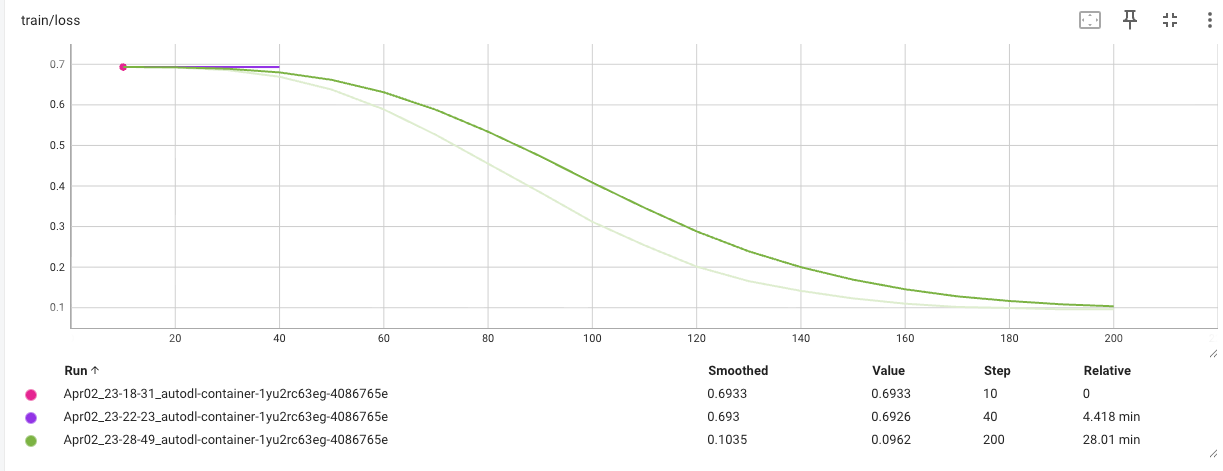

修改数据后的训练

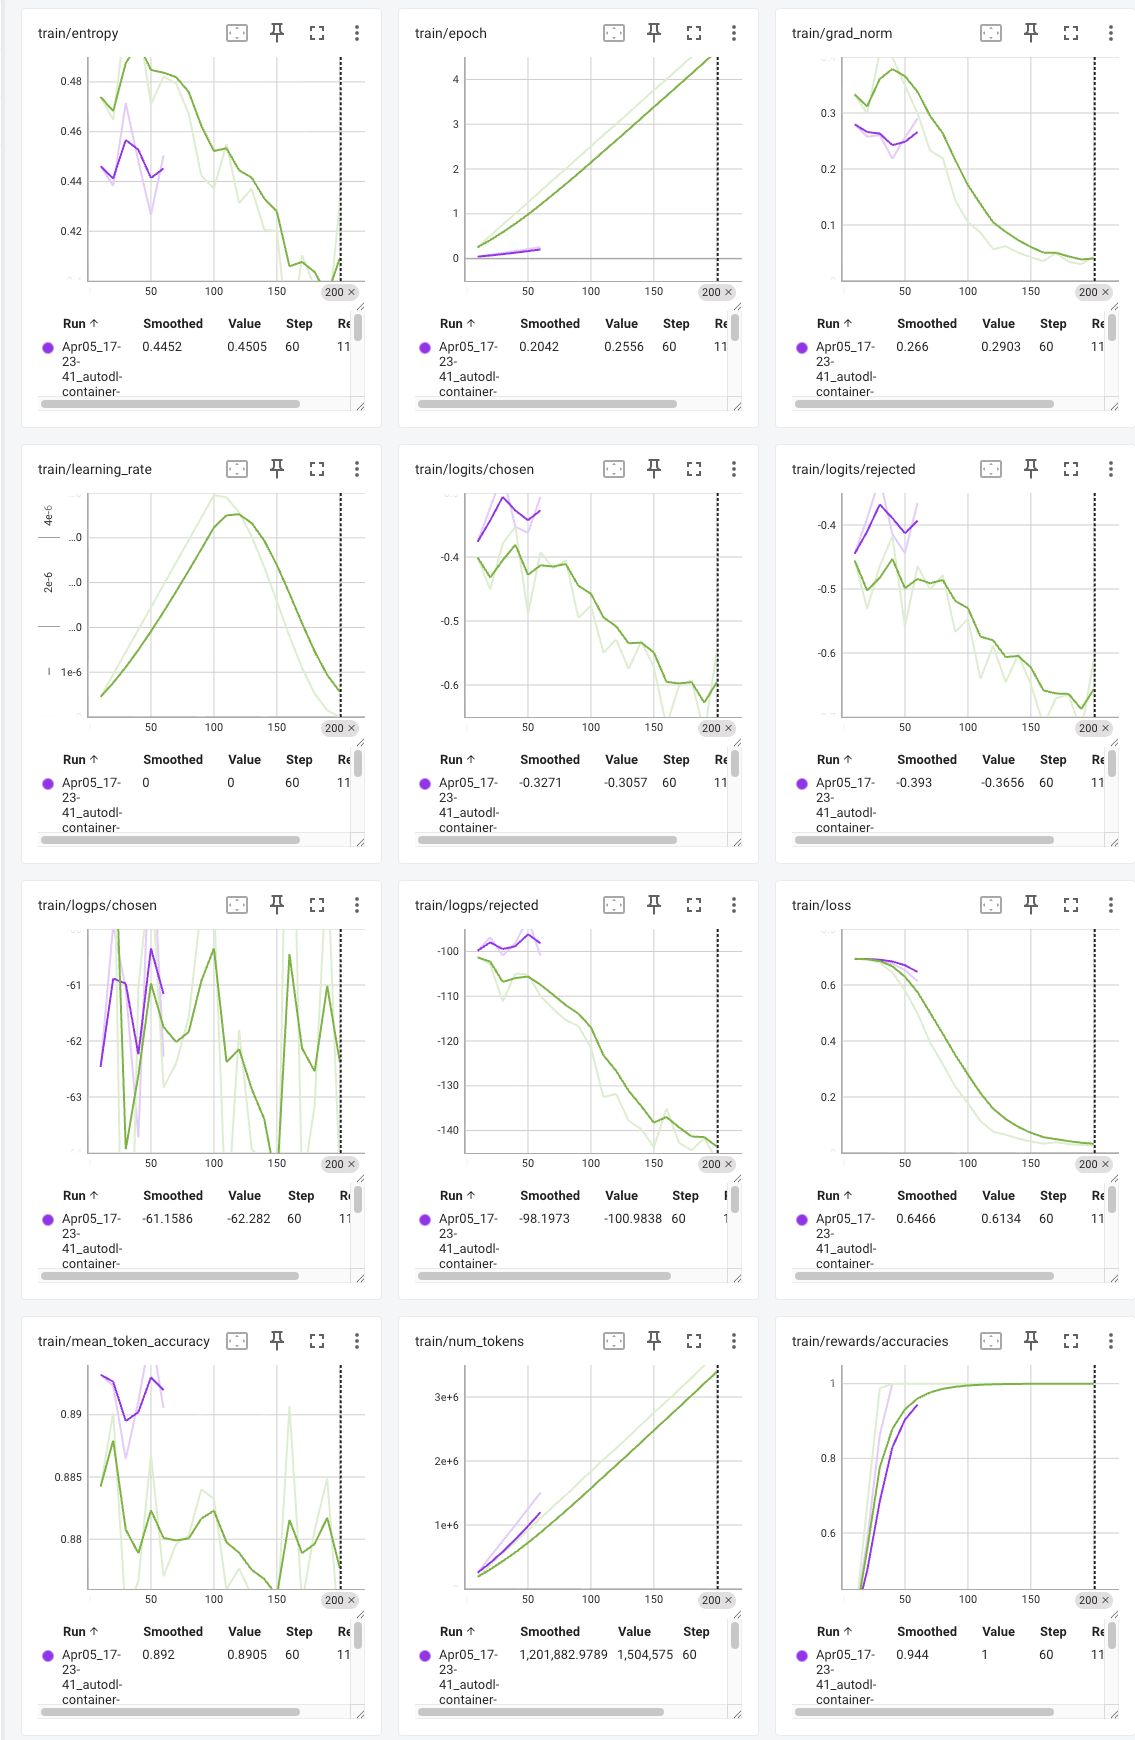

--max_source_length 1024 --max_target_length 512 改成 512 / 256 之后（绿色），训练“更激进、更有效率”，但也更不稳定、更偏向短样本分布；而原来的紫色配置则是更稳、更保守，但优化推进更慢。

这其实已经告诉你一个结论：

512/256 更适合作为“先把 DPO 跑通、先建立偏好能力”的工程配置；
1024/512 更像“保留更完整推理上下文，但训练成本更高”的研究配置。

再结合 train/entropy 看，会更清楚。绿色 entropy 整体比紫色更高一些，且波动幅度也更大。entropy 高不一定坏，它表示输出分布没有那么快塌缩，模型还保留一定探索/不确定性；但在你这组图里，绿色不是“稳定地高”，而是“抖着高”，这更像是：模型在短长度下更新更剧烈，分布变化更频繁。

这和前面 logit / logps 的观察是统一的：绿色优化更猛，但稳定性更差。

再看 train/grad_norm。绿色的 grad norm 基本始终高于紫色，而且中间还有比较明显的抬升。这其实非常关键，因为它说明缩短长度后，虽然显存压力降了，但每一步参数更新“冲击力”反而更大了。很多人会误以为“长度缩短 = 训练更稳定”，其实不一定。长度缩短通常会让：

每 step 更便宜；
loss 更容易下降

但也可能让：

梯度更尖锐；
更容易过拟合当前 pair；
更容易学到“局部偏好模板”

在训练集上 chosen/rejected 区分更好了，但真实测试时对长题干、多轮上下文、表格条件的利用反而下降。


## 评估：SFT vs SFT+DPO

（当前主测 FinQA + ConvFinQA）

按照 `README_fingpt.md` 的 fix 计划，这里比较 `SFT` 和 `DPO`：
- 任务结果：`answer_accuracy`、`program_accuracy`、`numeric_parse_rate`
- 输出质量：`final_answer_coverage`、`program_section_coverage`、`structured_response_coverage`、`avg_prediction_chars`

评测设置：
- `base`：基座模型
- `sft`：`SFT` merge 后模型
- `dpo`：以 `SFT` merge 模型为 base，再挂载 `DPO` LoRA adapter
- `ConvFinQA`：优先 `dev_turn.json`
- `FinQA`：优先 `test.json`，不存在则回退 `dev.json`

### benchmark 快速评估（base vs sft1 vs sft1+dpo）

目标：快速跑出一版可比较结果，而不是追求完整 benchmark。

默认比较三组模型：
- `base`：基座模型
- `sft1`：`SFT1_MERGED_OUT`
- `dpo`：以 `SFT1_MERGED_OUT` 为 base，挂载 `DPO_OUT` adapter

快速评估策略：
- `ConvFinQA` 只抽小样本
- `FinQA` 只抽小样本
- `temperature=0.0`
- `max_new_tokens` 限制为较小值

重点看两类指标：
- 任务结果：`answer_accuracy`、`program_accuracy`、`numeric_parse_rate`
- 输出质量：`final_answer_coverage`、`program_section_coverage`、`structured_response_coverage`


In [ ]:
import importlib.util

QUICK_BENCHMARK_DIR = OUTPUT_ROOT / "benchmark_quick_sft1_dpo"
QUICK_CONVFINQA_MAX_SAMPLES = 4
QUICK_FINQA_MAX_SAMPLES = 4
QUICK_MAX_NEW_TOKENS = 256
QUICK_USE_4BIT = importlib.util.find_spec('bitsandbytes') is not None

SFT1_QUICK_MODEL = SFT1_MERGED_OUT
CONVFINQA_EVAL_FILE = RAW_CACHE_DIR / "convfinqa_turn/dev_turn.json"
FINQA_EVAL_FILE = RAW_CACHE_DIR / "finqa/test.json"
if not FINQA_EVAL_FILE.exists():
    FINQA_EVAL_FILE = RAW_CACHE_DIR / "finqa/dev.json"

required_paths = {
    "SFT1 merged model": SFT1_QUICK_MODEL / "config.json",
    "DPO adapter": DPO_OUT / "adapter_config.json",
    "ConvFinQA eval file": CONVFINQA_EVAL_FILE,
    "FinQA eval file": FINQA_EVAL_FILE,
}
missing = {name: path for name, path in required_paths.items() if not path.exists()}
if missing:
    raise FileNotFoundError("
".join(f"{name} not found: {path}" for name, path in missing.items()))

print(f"SFT1 quick model: {SFT1_QUICK_MODEL}")
print(f"DPO adapter: {DPO_OUT}")
print(f"ConvFinQA eval file: {CONVFINQA_EVAL_FILE}")
print(f"FinQA eval file: {FINQA_EVAL_FILE}")
print(f"Quick eval samples: convfinqa={QUICK_CONVFINQA_MAX_SAMPLES}, finqa={QUICK_FINQA_MAX_SAMPLES}")
print(f"Quick eval max_new_tokens: {QUICK_MAX_NEW_TOKENS}")
print(f"Quick eval loading mode: {'4-bit' if QUICK_USE_4BIT else 'default dtype (bitsandbytes not installed)'}")
print("Quick eval comparison: base vs sft1 vs dpo")

quick_benchmark_cmd = [
    'python', '-m', 'evaluation.evaluate_financial_benchmarks',
    '--tokenizer_path', BASE_MODEL,
    '--model_entry', f'base={BASE_MODEL}',
    '--model_entry', f'sft1={SFT1_QUICK_MODEL}',
    '--model_entry', f'dpo={SFT1_QUICK_MODEL}',
    '--adapter_entry', f'dpo={DPO_OUT}',
    '--convfinqa_test_file', str(CONVFINQA_EVAL_FILE),
    '--convfinqa_max_samples', str(QUICK_CONVFINQA_MAX_SAMPLES),
    '--finqa_test_file', str(FINQA_EVAL_FILE),
    '--finqa_max_samples', str(QUICK_FINQA_MAX_SAMPLES),
    '--max_new_tokens', str(QUICK_MAX_NEW_TOKENS),
    '--temperature', '0.0',
    '--output_dir', str(QUICK_BENCHMARK_DIR),
]
if QUICK_USE_4BIT:
    quick_benchmark_cmd.append('--load_in_4bit')
print(' '.join(shlex.quote(part) for part in quick_benchmark_cmd))
subprocess.run(quick_benchmark_cmd, check=True)


In [ ]:

summary_csv = QUICK_BENCHMARK_DIR / 'benchmark_summary.csv'
summary_json = QUICK_BENCHMARK_DIR / 'benchmark_summary.json'
if summary_csv.exists():
    summary_df = pd.read_csv(summary_csv)
    display(summary_df)
    focus_cols = [
        'model_name', 'task_name', 'answer_accuracy', 'program_accuracy',
        'numeric_parse_rate', 'final_answer_coverage',
        'program_section_coverage', 'structured_response_coverage',
        'avg_prediction_chars'
    ]
    display(summary_df[[c for c in focus_cols if c in summary_df.columns]])
elif summary_json.exists():
    display(pd.DataFrame(json.loads(summary_json.read_text(encoding='utf-8'))))

## GRPO


### GRPO 使用原则

- 这个 notebook 的金融 GRPO 流程只使用 `financial_grpo_training.py`。
- `grpo_training.py` 是通用 R1 / GSM8K 风格脚本，依赖 `question/answer` 和 `<think><answer>` 格式，不适合当前金融结构化推理流程。
- GRPO 训练阶段的 `eval_strategy` 只是从训练集里切一部分 holdout 做过程监控，不等价于真正的 benchmark 评估。
- 最终是否有效，要看 `evaluate_financial_benchmarks.py` 在 `FinQA / ConvFinQA` 上的 `answer_accuracy`、`program_accuracy` 和结构覆盖率。
- 当前 `financial_grpo_training.py` 的 reward 里，程序一致性仍是轻量启发式；训练后必须用 benchmark 复核，不要只看训练日志。


### GRPO 可执行流程（金融专用）

默认先用 `SFT_MERGED_OUT` 作为 GRPO 起点，只走 `financial_grpo_training.py`：
- 第一步：从 `FinQA` + `ConvFinQA` 原始训练集构造金融 GRPO 数据。
- 第二步：运行金融专用 GRPO 训练，训练内 holdout 只用于观察 reward/稳定性。
- 第三步：训练结束后，用快速 benchmark 比较 `base / sft / dpo / grpo`。

第一版先不叠加 `DPO -> GRPO merged`，先降低变量；如果 `SFT -> GRPO` 有效，再做 `SFT+DPO -> GRPO`。


In [ ]:
GRPO_DIR = DATA_DIR / 'grpo'
GRPO_TRAIN_DIR = GRPO_DIR / 'train_dir'
GRPO_TRAIN_FILE = GRPO_TRAIN_DIR / 'train_grpo.jsonl'
GRPO_OUT = OUTPUT_ROOT / 'grpo_lora'
GRPO_MERGED_OUT = OUTPUT_ROOT / 'grpo_merged'
for d in [GRPO_DIR, GRPO_TRAIN_DIR, GRPO_OUT, GRPO_MERGED_OUT]:
    d.mkdir(parents=True, exist_ok=True)

grpo_build_cmd = [
    'python', 'build_financial_grpo_dataset.py',
    '--source_spec', f"finqa={RAW_CACHE_DIR / 'finqa' / 'train.json'}",
    '--source_spec', f"convfinqa_turn={RAW_CACHE_DIR / 'convfinqa_turn' / 'train_turn.json'}",
    '--output_file', str(GRPO_TRAIN_FILE),
]
print(' '.join(grpo_build_cmd))
subprocess.run(grpo_build_cmd, check=True)

rows = []
with GRPO_TRAIN_FILE.open('r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 3:
            break
        rows.append(json.loads(line))

display(pd.DataFrame([
    {
        'task_name': r.get('task_name', ''),
        'source_dataset': r.get('source_dataset', ''),
        'record_id': r.get('record_id', ''),
        'prompt_preview': str(r.get('prompt', ''))[:120],
        'answer': r.get('answer', ''),
        'gold_program': str(r.get('gold_program', ''))[:120],
    }
    for r in rows
]))



In [ ]:
GRPO_VALIDATION_SPLIT_PERCENTAGE = 10
GRPO_NUM_GENERATIONS = 4
GRPO_MAX_PROMPT_LENGTH = 1024
GRPO_MAX_COMPLETION_LENGTH = 256

grpo_cmd = [
    'python', 'financial_grpo_training.py',
    '--model_name_or_path', str(SFT_MERGED_OUT),
    '--tokenizer_name_or_path', BASE_MODEL,
    '--train_file_dir', str(GRPO_TRAIN_DIR),
    '--validation_split_percentage', str(GRPO_VALIDATION_SPLIT_PERCENTAGE),
    '--use_peft', 'True',
    '--lora_target_modules', 'all',
    '--lora_r', '8',
    '--lora_alpha', '16',
    '--lora_dropout', '0.05',
    '--learning_rate', '5e-6',
    '--max_prompt_length', str(GRPO_MAX_PROMPT_LENGTH),
    '--max_completion_length', str(GRPO_MAX_COMPLETION_LENGTH),
    '--num_generations', str(GRPO_NUM_GENERATIONS),
    '--per_device_train_batch_size', '1',
    '--gradient_accumulation_steps', '8',
    '--num_train_epochs', '1',
    '--eval_strategy', 'steps',
    '--eval_steps', '50',
    '--save_steps', '100',
    '--logging_steps', '10',
    '--bf16', 'True',
    '--dtype', 'bfloat16',
    '--output_dir', str(GRPO_OUT),
]
print(' '.join(grpo_cmd))
print('Note: training eval here is only an internal holdout split, not benchmark evaluation.')
# subprocess.run(grpo_cmd, check=True)


In [ ]:
# Optional: run the GRPO command after checking GPU memory and data size.
# subprocess.run(grpo_cmd, check=True)


### GRPO Benchmark

训练结束后，不看训练内 holdout 指标做结论；统一用同一套 benchmark 脚本比较 `base / sft / dpo / grpo`。


In [ ]:
quick_benchmark_grpo_cmd = [
    'python', 'evaluate_financial_benchmarks.py',
    '--tokenizer_path', BASE_MODEL,
    '--model_entry', f'base={BASE_MODEL}',
    '--model_entry', f'sft={SFT_MERGED_OUT}',
    '--model_entry', f'dpo={SFT_MERGED_OUT}',
    '--model_entry', f'grpo={SFT_MERGED_OUT}',
    '--adapter_entry', f'dpo={DPO_OUT}',
    '--adapter_entry', f'grpo={GRPO_OUT}',
    '--convfinqa_test_file', str(CONVFINQA_EVAL_FILE),
    '--convfinqa_max_samples', str(QUICK_CONVFINQA_MAX_SAMPLES),
    '--finqa_test_file', str(FINQA_EVAL_FILE),
    '--finqa_max_samples', str(QUICK_FINQA_MAX_SAMPLES),
    '--max_new_tokens', str(QUICK_MAX_NEW_TOKENS),
    '--temperature', '0.0',
    '--load_in_4bit',
    '--output_dir', str(REPORT_DIR / 'benchmark_quick_base_sft_dpo_grpo'),
]
print(' '.join(quick_benchmark_grpo_cmd))
# subprocess.run(quick_benchmark_grpo_cmd, check=True)
